# Confronto Diffusori (unificato)

Questo notebook e' il file unico di confronto fra tutti i diffusori del progetto.
Sostituisce e ingloba i due file storici che erano usati per generare i plot
della presentazione D1 e del confronto VAE, ora archiviati come parti B e C
sotto forma di celle con output statici preservati.

## Struttura

- **Parte A - Confronto sistematico attuale** (contenuto originale del nuovo 04c):
  confronta 5 pipeline generative (`04b`, `04b2`, `04b3`, `03b`, `03c`) sullo stesso
  test set reale, con bar chart per metrica/classe, radar PRDC, delta D5 e D6.
  Queste celle sono **eseguibili** e usano i JSON di metriche gia' salvati.
- **Parte B - Archivio: from-scratch vs fine-tuned** (era
  `comparisons/diffusers/00y_fromscratch_vs_finetuned.ipynb`): raccoglie le celle con plot
  storici usati nella slide D1 (griglia principale reali vs from-scratch vs
  fine-tuned, griglie compatte, bar chart delle metriche finali, figura filtro
  vs RAW). **Non pensate per essere rieseguite:** il loro valore e' l'output
  gia' presente nel file (immagini embedded), che riproduce esattamente i plot
  della presentazione.
- **Parte C - Archivio: VAE zero vs SD-VAE vs fine-tuned** (era `04c1`):
  idem, plot storici del confronto VAE-zero / SD-VAE / VAE fine-tuned.

I due file precedenti (`comparisons/diffusers/00y_fromscratch_vs_finetuned.ipynb` e
`comparisons/diffusers/00x_vae_comparison.ipynb`) sono stati eliminati.


---

# Parte A - Confronto sistematico attuale (5-way)

Contenuto originale del notebook `comparisons/diffusers/00z_diffuser_comparison.ipynb` prima della
unificazione. Celle eseguibili sui JSON di metriche gia' salvati.


## 1. Percorsi progetto e sorgenti dei cinque esperimenti

In [ ]:
# === Bootstrap unificato notebooks/ ===
# Funziona dalla root del progetto e da ogni sottocartella della struttura notebooks/.
import sys as _sys
from pathlib import Path as _Path


def _find_mammo_root():
    for _candidate in [_Path.cwd().resolve(), *_Path.cwd().resolve().parents]:
        if _candidate.name == "MammoDiffusion":
            return _candidate
        if (_candidate / "data").is_dir() and (_candidate / "notebooks").is_dir():
            return _candidate
    raise FileNotFoundError("Root MammoDiffusion non trovata da " + str(_Path.cwd()))


PROJECT_ROOT = _find_mammo_root()
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
UTILITY_DIR = NOTEBOOKS_DIR / "utility"
for _path in (str(UTILITY_DIR), str(NOTEBOOKS_DIR)):
    if _path not in _sys.path:
        _sys.path.insert(0, _path)

BASE = PROJECT_ROOT
BASE_DIR = PROJECT_ROOT
BASE_PATH = str(PROJECT_ROOT) + "/"
# === Fine bootstrap unificato ===

from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image as PILImage

PROJECT_NAME = 'MammoDiffusion'
PROJECT_ROOT_OVERRIDE = None


def find_project_root(project_name=PROJECT_NAME, override=PROJECT_ROOT_OVERRIDE):
    if override is not None:
        return Path(override).expanduser().resolve()
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if candidate.name == project_name or ((candidate / 'data').exists() and (candidate / 'notebooks').exists()):
            return candidate
    raise FileNotFoundError('Root MammoDiffusion non trovata.')


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / 'data'
SYNTHETIC_DIR = DATA_DIR / 'synthetic'
DATA_PROCESSED_DIR = DATA_DIR / 'processed'

# Sorgenti metriche (JSON gia' salvati dai rispettivi notebook)
SOURCES = {
    'FromScratch_VAEzero': {
        'positive_json': PROJECT_ROOT / 'results' / 'diffusers/06_ldm_extra1361_fromscratch' / 'metrics' / 'positive' / 'final_filtered_vs_test.json',
        'negative_json_candidates': [
            PROJECT_ROOT / 'results' / 'diffusers/06_ldm_extra1361_fromscratch' / 'metrics' / 'negative' / 'final_filtered_vs_test.json',
        ],
        'schema': 'legacy_flat',
        'qualitative_dirs': {
            'positive': SYNTHETIC_DIR / 'fromscratch' / 'positive',
            'negative': SYNTHETIC_DIR / 'fromscratch' / 'negative',
        },
    },
    'FromScratch_SD_VAE': {
        'positive_json': PROJECT_ROOT / 'results' / 'diffusers/07_ldm_sdvae_extra1361' / 'metrics' / 'positive' / 'final_filtered_vs_test.json',
        'negative_json_candidates': [
            PROJECT_ROOT / 'results' / 'diffusers/07_ldm_sdvae_extra1361' / 'metrics' / 'negative' / 'final_filtered_vs_test.json',
            PROJECT_ROOT / 'results' / 'diffusers/07_ldm_sdvae_extra1361' / 'metrics' / 'final_filtered_vs_test_negative.json',
        ],
        'schema': 'legacy_flat',
        'qualitative_dirs': {
            'positive': SYNTHETIC_DIR / 'fromscratch_new' / 'positive',
            'negative': SYNTHETIC_DIR / 'fromscratch_new' / 'negative',
        },
    },
    'FromScratch_SD_VAE_v3': {
        'positive_json': PROJECT_ROOT / 'results' / 'diffusers/08_ldm_v3_sdvae_fromscratch' / 'metrics' / 'positive' / 'final_filtered_vs_test.json',
        'negative_json_candidates': [
            PROJECT_ROOT / 'results' / 'diffusers/08_ldm_v3_sdvae_fromscratch' / 'metrics' / 'negative' / 'final_filtered_vs_test.json',
            PROJECT_ROOT / 'results' / 'diffusers/08_ldm_v3_sdvae_fromscratch' / 'metrics' / 'final_filtered_vs_test_negative.json',
        ],
        'schema': 'legacy_flat',
        'qualitative_dirs': {
            'positive': SYNTHETIC_DIR / 'fromscratch_v3' / 'positive',
            'negative': SYNTHETIC_DIR / 'fromscratch_v3' / 'negative',
        },
    },
    'FineTuned_SD2.1': {
        'combined_json': PROJECT_ROOT / 'results' / 'diffusers/02_sd21_filtered_100steps' / 'metrics' / 'final_test_metrics.json',
        'schema': 'per_class',
        'qualitative_dirs': {
            'positive': SYNTHETIC_DIR / 'fine_tuned' / 'positive',
            'negative': SYNTHETIC_DIR / 'fine_tuned' / 'negative',
        },
    },
    'FineTuned_SD2.1_VAEFT': {
        'combined_json': PROJECT_ROOT / 'results' / 'diffusers/03_sd21_vae_finetuned' / 'metrics' / 'final_test_metrics.json',
        'schema': 'per_class',
        'qualitative_dirs': {
            'positive': SYNTHETIC_DIR / 'fine_tuned_vaeft' / 'positive',
            'negative': SYNTHETIC_DIR / 'fine_tuned_vaeft' / 'negative',
        },
    },
}

# 04b3 puo' usare il VAE standard o quello fine-tuned di 03c (USE_VAE_FT_FROM_03C):
# rileva quale dal training_manifest.json che train_ldm_v2.py scrive sempre, invece di
# assumerlo, cosi' l'etichetta nei grafici distingue chiaramente le due varianti senza
# che serva cambiare cartella di output o rompere 04b/04b2.
V3_EXPERIMENT_DIR = PROJECT_ROOT / 'experiments' / 'diffusers/08_ldm_v3_sdvae_fromscratch'
V3_TRAINING_MANIFEST = V3_EXPERIMENT_DIR / 'training_manifest.json'
V3_PIPELINE_LABEL = 'FromScratch_SD_VAE_v3'
if V3_TRAINING_MANIFEST.exists():
    try:
        with open(V3_TRAINING_MANIFEST, encoding='utf-8') as handle:
            v3_manifest = json.load(handle)
        if v3_manifest.get('uses_vae_ft_from_03c'):
            V3_PIPELINE_LABEL = 'FromScratch_SD_VAEFT_v3'
    except Exception as exc:
        print(f'training_manifest.json di 04b3 non leggibile, uso label di default: {exc}')
if V3_PIPELINE_LABEL != 'FromScratch_SD_VAE_v3':
    SOURCES[V3_PIPELINE_LABEL] = SOURCES.pop('FromScratch_SD_VAE_v3')
print('Label pipeline 04b3:', V3_PIPELINE_LABEL)

RESULTS_STAGE_NAME = 'comparisons/diffusers/00z_diffuser_comparison'
RESULTS_DIR = PROJECT_ROOT / 'results' / RESULTS_STAGE_NAME
PLOTS_DIR = RESULTS_DIR / 'plots'
METRICS_DIR = RESULTS_DIR / 'metrics'
for directory in [PLOTS_DIR, METRICS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('RESULTS_DIR :', RESULTS_DIR)
print(f'Sorgenti configurate: {len(SOURCES)}')

## 2. Caricamento metriche dai JSON gia' salvati

Due schemi:

- **`per_class`** (03b/03c): un unico JSON con `per_class.positive`, `per_class.negative` e `per_class.average`.
- **`legacy_flat`** (04b/04b2/04b3): un JSON per classe, con le metriche in `metrics` direttamente (radice o campo omonimo).

In [ ]:
METRIC_COLUMNS = ['FID', 'IS_mean', 'IS_std', 'precision', 'recall', 'density', 'coverage']


def read_json(path):
    path = Path(path)
    if not path.exists():
        return None
    with open(path, encoding='utf-8') as handle:
        return json.load(handle)


def row_from_metrics(pipeline, class_name, metrics, source_path):
    if metrics is None:
        return None
    return {
        'pipeline': pipeline,
        'class': class_name,
        'source_path': str(source_path),
        **{col: float(metrics.get(col, np.nan)) for col in METRIC_COLUMNS},
        'n_generated': int(metrics.get('n_generated', metrics.get('n_synthetic_filtered', 0))),
        'n_real_reference': int(metrics.get('n_real_reference', metrics.get('n_real_test', 0))),
    }


def load_per_class(payload, class_name):
    if not payload:
        return None
    return (payload.get('per_class') or {}).get(class_name)


def load_legacy_flat(payload):
    if not payload:
        return None
    return payload.get('metrics') or payload


rows = []
for pipeline, cfg in SOURCES.items():
    if cfg['schema'] == 'per_class':
        payload = read_json(cfg['combined_json'])
        source_path = cfg['combined_json']
        for class_name in ('positive', 'negative'):
            metrics = load_per_class(payload, class_name)
            row = row_from_metrics(pipeline, class_name, metrics, source_path)
            if row:
                rows.append(row)
            else:
                print(f'  MISSING {pipeline}/{class_name} -> {source_path}')
    elif cfg['schema'] == 'legacy_flat':
        # positive
        pos_payload = read_json(cfg['positive_json'])
        pos_metrics = load_legacy_flat(pos_payload)
        pos_row = row_from_metrics(pipeline, 'positive', pos_metrics, cfg['positive_json'])
        if pos_row:
            rows.append(pos_row)
        else:
            print(f'  MISSING {pipeline}/positive -> {cfg["positive_json"]}')
        # negative (prova piu\' path candidati)
        neg_found = False
        for candidate in cfg.get('negative_json_candidates', []):
            neg_payload = read_json(candidate)
            neg_metrics = load_legacy_flat(neg_payload)
            neg_row = row_from_metrics(pipeline, 'negative', neg_metrics, candidate)
            if neg_row:
                rows.append(neg_row)
                neg_found = True
                break
        if not neg_found:
            print(f'  MISSING {pipeline}/negative in candidates: {cfg.get("negative_json_candidates", [])}')

df_long = pd.DataFrame(rows)
long_csv = METRICS_DIR / 'diffusers_metrics_long.csv'
df_long.to_csv(long_csv, index=False)
print(f'\nRighe caricate: {len(df_long)}. CSV: {long_csv}')
df_long

## 3. Medie per pipeline (sulle classi disponibili) e miglior from-scratch

In [ ]:
if df_long.empty:
    raise RuntimeError('Nessuna metrica caricata: verifica i path in SOURCES.')

summary_rows = []
for pipeline, group in df_long.groupby('pipeline'):
    row = {'pipeline': pipeline, 'n_classes_available': int(group['class'].nunique())}
    for metric in METRIC_COLUMNS:
        row[metric] = float(group[metric].mean())
    row['n_generated_total'] = int(group['n_generated'].sum())
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows).sort_values('FID').reset_index(drop=True)
summary_csv = METRICS_DIR / 'diffusers_summary_by_pipeline.csv'
df_summary.to_csv(summary_csv, index=False)
print('Salvato:', summary_csv)
df_summary

In [ ]:
HIGHER_IS_BETTER = {
    'FID': False, 'IS_mean': True, 'IS_std': False,
    'precision': True, 'recall': True, 'density': True, 'coverage': True,
}
FROM_SCRATCH_PIPELINES = ['FromScratch_VAEzero', 'FromScratch_SD_VAE', V3_PIPELINE_LABEL]
FINE_TUNED_PIPELINES = ['FineTuned_SD2.1', 'FineTuned_SD2.1_VAEFT']

comparison_rows = []
for class_name in sorted(df_long['class'].unique()):
    class_df = df_long[df_long['class'] == class_name]
    fs_df = class_df[class_df['pipeline'].isin(FROM_SCRATCH_PIPELINES)]
    ft_df = class_df[class_df['pipeline'].isin(FINE_TUNED_PIPELINES)]
    if fs_df.empty or ft_df.empty:
        continue
    for metric, higher in HIGHER_IS_BETTER.items():
        fs_valid = fs_df.dropna(subset=[metric])
        ft_valid = ft_df.dropna(subset=[metric])
        if fs_valid.empty or ft_valid.empty:
            continue
        if higher:
            best_fs_idx = fs_valid[metric].idxmax()
            best_ft_idx = ft_valid[metric].idxmax()
            fs_val = float(fs_valid.loc[best_fs_idx, metric])
            ft_val = float(ft_valid.loc[best_ft_idx, metric])
            overall_winner = fs_valid.loc[best_fs_idx, 'pipeline'] if fs_val >= ft_val else ft_valid.loc[best_ft_idx, 'pipeline']
        else:
            best_fs_idx = fs_valid[metric].idxmin()
            best_ft_idx = ft_valid[metric].idxmin()
            fs_val = float(fs_valid.loc[best_fs_idx, metric])
            ft_val = float(ft_valid.loc[best_ft_idx, metric])
            overall_winner = fs_valid.loc[best_fs_idx, 'pipeline'] if fs_val <= ft_val else ft_valid.loc[best_ft_idx, 'pipeline']
        comparison_rows.append({
            'class': class_name,
            'metric': metric,
            'higher_is_better': higher,
            'best_fromscratch': fs_valid.loc[best_fs_idx, 'pipeline'],
            'best_fromscratch_value': fs_val,
            'best_finetuned': ft_valid.loc[best_ft_idx, 'pipeline'],
            'best_finetuned_value': ft_val,
            'overall_winner': overall_winner,
        })

df_best = pd.DataFrame(comparison_rows)
best_csv = METRICS_DIR / 'best_fromscratch_vs_finetuned.csv'
df_best.to_csv(best_csv, index=False)
print('Salvato:', best_csv)
df_best

## 4. Bar chart per metrica e classe (5-way)

In [ ]:
PLOT_COLORS = {
    'FromScratch_VAEzero':     '#c0392b',
    'FromScratch_SD_VAE':      '#1f77b4',
    'FromScratch_SD_VAE_v3':   '#17becf',
    'FromScratch_SD_VAEFT_v3': '#0e7c8f',
    'FineTuned_SD2.1':         '#2e8b57',
    'FineTuned_SD2.1_VAEFT':   '#8e44ad',
}
metric_specs = [
    ('FID',       'FID (piu\' basso = meglio)'),
    ('IS_mean',   'Inception Score'),
    ('precision', 'Precision'),
    ('recall',    'Recall'),
    ('density',   'Density'),
    ('coverage',  'Coverage'),
]

for class_name, class_df in df_long.groupby('class'):
    fig, axes = plt.subplots(2, 3, figsize=(17, 9))
    for ax, (metric, title) in zip(axes.ravel(), metric_specs):
        plot_df = class_df.dropna(subset=[metric])
        colors = [PLOT_COLORS.get(p, '#888') for p in plot_df['pipeline']]
        bars = ax.bar(plot_df['pipeline'], plot_df[metric], color=colors)
        ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)
        top = max(float(plot_df[metric].max()), 0)
        ax.set_ylim(top=top * 1.18 if top > 0 else 1)
        ax.set_title(title)
        ax.grid(axis='y', alpha=0.25)
        plt.setp(ax.get_xticklabels(), rotation=25, ha='right', fontsize=8)
    fig.suptitle(f'Metriche generative - classe {class_name}', fontsize=14)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    out_path = PLOTS_DIR / f'metrics_by_pipeline_{class_name}.png'
    fig.savefig(out_path, dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print('Salvato:', out_path)

## 5. Radar PRDC per classe

In [ ]:
radar_metrics = ['precision', 'recall', 'density', 'coverage']
for class_name, class_df in df_long.groupby('class'):
    angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw={'polar': True})
    for _, row in class_df.iterrows():
        values = [float(row[m]) if not pd.isna(row[m]) else 0.0 for m in radar_metrics]
        values += values[:1]
        color = PLOT_COLORS.get(row['pipeline'], '#888')
        ax.plot(angles, values, label=row['pipeline'], color=color, linewidth=2)
        ax.fill(angles, values, alpha=0.12, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([m.capitalize() for m in radar_metrics])
    ax.set_ylim(0, 1.05)
    ax.set_title(f'PRDC radar - classe {class_name}', pad=25)
    ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.12), fontsize=8)
    out_path = PLOTS_DIR / f'prdc_radar_{class_name}.png'
    fig.savefig(out_path, dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print('Salvato:', out_path)

## 6. Delta VAE adattato vs VAE congelato (03c vs 03b, D5)

Calcolo esplicito dei delta % orientati al miglioramento tra la variante `FineTuned_SD2.1_VAEFT`
e la baseline `FineTuned_SD2.1`. Serve a rispondere in modo diretto alla domanda D5.

In [ ]:
def delta_orientato(baseline, candidate, higher_is_better):
    if baseline is None or candidate is None or baseline == 0 or pd.isna(baseline) or pd.isna(candidate):
        return None
    raw = (candidate - baseline) / abs(baseline) * 100.0
    return round(float(raw if higher_is_better else -raw), 2)


vaeft_rows = []
for class_name in sorted(df_long['class'].unique()):
    b = df_long[(df_long['pipeline'] == 'FineTuned_SD2.1') & (df_long['class'] == class_name)]
    c = df_long[(df_long['pipeline'] == 'FineTuned_SD2.1_VAEFT') & (df_long['class'] == class_name)]
    if b.empty or c.empty:
        continue
    row = {'class': class_name}
    for metric, higher in HIGHER_IS_BETTER.items():
        row[f'{metric}_baseline'] = float(b.iloc[0][metric])
        row[f'{metric}_vaeft']    = float(c.iloc[0][metric])
        row[f'{metric}_delta_pct_oriented'] = delta_orientato(float(b.iloc[0][metric]), float(c.iloc[0][metric]), higher)
    vaeft_rows.append(row)

df_vaeft = pd.DataFrame(vaeft_rows)
if df_vaeft.empty:
    print('Uno tra 03b e 03c non ha metriche finali disponibili: sezione D5 saltata.')
else:
    df_vaeft.to_csv(METRICS_DIR / 'delta_vaeft_vs_baseline_ft.csv', index=False)
    display_cols = ['class'] + [f'{m}_delta_pct_oriented' for m in HIGHER_IS_BETTER]
    print('Delta % orientati al miglioramento (positivo = 03c meglio di 03b):')
    print(df_vaeft[display_cols].to_string(index=False))

## 7. Delta v3 vs v2 (04b3 vs 04b2, effetto architettura + v-pred + min-SNR)

Confronto analogo al precedente ma tra `FromScratch_SD_VAE_v3` (04b3) e `FromScratch_SD_VAE` (04b2).
Isolato dal cambio di VAE (che qui rimane SD-VAE congelato), il delta misura quanto contano U-Net rivista,
v-prediction e min-SNR.

In [ ]:
v3_rows = []
for class_name in sorted(df_long['class'].unique()):
    b = df_long[(df_long['pipeline'] == 'FromScratch_SD_VAE') & (df_long['class'] == class_name)]
    c = df_long[(df_long['pipeline'] == V3_PIPELINE_LABEL) & (df_long['class'] == class_name)]
    if b.empty or c.empty:
        continue
    row = {'class': class_name}
    for metric, higher in HIGHER_IS_BETTER.items():
        row[f'{metric}_v2']  = float(b.iloc[0][metric])
        row[f'{metric}_v3']  = float(c.iloc[0][metric])
        row[f'{metric}_delta_pct_oriented'] = delta_orientato(float(b.iloc[0][metric]), float(c.iloc[0][metric]), higher)
    v3_rows.append(row)

df_v3 = pd.DataFrame(v3_rows)
if df_v3.empty:
    print('04b3 non ha ancora metriche finali disponibili: sezione v3 saltata.')
else:
    df_v3.to_csv(METRICS_DIR / 'delta_v3_vs_v2_fromscratch.csv', index=False)
    display_cols = ['class'] + [f'{m}_delta_pct_oriented' for m in HIGHER_IS_BETTER]
    print('Delta % orientati al miglioramento (positivo = v3 meglio di v2 SD-VAE frozen):')
    print(df_v3[display_cols].to_string(index=False))

## 8. Griglia qualitativa 5-way (per classe)

In [ ]:
IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg'}


def first_paths(directory, n=2):
    directory = Path(directory)
    if not directory.is_dir():
        return []
    return sorted(p for p in directory.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)[:n]


groups = {'Reali': {
    'positive': DATA_PROCESSED_DIR / 'test' / '1',
    'negative': DATA_PROCESSED_DIR / 'test' / '0',
}}
for pipeline, cfg in SOURCES.items():
    groups[pipeline] = cfg['qualitative_dirs']

for class_name in ['positive', 'negative']:
    selected = {name: first_paths(paths[class_name], n=2) for name, paths in groups.items()}
    n_rows = 2
    n_cols = len(groups)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.6 * n_cols, 3 * n_rows))
    for col, (group_name, paths) in enumerate(selected.items()):
        for row in range(n_rows):
            ax = axes[row, col]
            if row < len(paths):
                with PILImage.open(paths[row]) as image:
                    ax.imshow(np.asarray(image.convert('L')), cmap='gray', vmin=0, vmax=255)
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0:
                ax.set_title(group_name, fontsize=9)
    fig.suptitle(f'Griglia qualitativa 5-way - classe {class_name}', fontsize=14)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    out_path = PLOTS_DIR / f'qualitative_grid_{class_name}.png'
    fig.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print('Salvato:', out_path)

---

# Parte B - Archivio: from-scratch vs fine-tuned (celle con plot storici)

Contenuto originale di `comparisons/diffusers/00y_fromscratch_vs_finetuned.ipynb`.
**Le celle qui sotto non sono pensate per essere rieseguite**: il valore che
vogliamo preservare e' l'output gia' presente nel file (immagini embedded),
cioe' i plot usati nella presentazione D1. Se un giorno serve rigenerarli,
tenere presente che le variabili/path riferite in queste celle sono quelle del
vecchio notebook e potrebbero non allinearsi ai path/variabili definiti in
Parte A.


# Confronto: diffusore from-scratch (04b) vs diffusore fine-tuned (03b)

Notebook di sola analisi: legge esclusivamente gli artefatti gia' prodotti da

- `02_SD21_Filtered_100steps.ipynb` -> Stable Diffusion 2.1 **fine-tuned** sulle mammografie RSNA (100 inference step, filtro adattivo, 1361 immagini/classe);
- `06_LDM_Extra1361_FromScratch.ipynb` -> Latent Diffusion Model Keras addestrato **from scratch** (VAE + UNet, 80000 step, filtro adattivo, 1361 immagini per la sola classe positiva).

Nessuna immagine viene generata qui e non serve la GPU. I due esperimenti non sono perfettamente simmetrici: il modello from-scratch ha prodotto finora soltanto la classe positiva (tumorale), mentre il fine-tuned ha prodotto entrambe le classi. Dove il confronto a tre vie (reali / from-scratch / fine-tuned) non e' possibile, il notebook lo segnala invece di nasconderlo.

Contenuto:

1. griglia reali vs from-scratch vs fine-tuned (classe positiva);
2. griglia reali vs fine-tuned (classe negativa, from-scratch non disponibile);
3. metriche finali sul test set (FID, Inception Score, PRDC);
4. effetto del filtro adattivo sul validation set (raw vs filtrate);
5. traiettoria di selezione del checkpoint durante il training;
6. costo energetico e CO2 stimati delle due pipeline;
7. tabella di riepilogo.


## 1. Percorsi progetto e sorgenti dei due esperimenti

In [1]:
from pathlib import Path
import sys

PROJECT_NAME = "MammoDiffusion"
RESULTS_STAGE_NAME = "comparisons/diffusers/00y_fromscratch_vs_finetuned"

# Se serve su Colab/Drive:
# PROJECT_ROOT_OVERRIDE = Path("/content/drive/MyDrive/MammoDiffusion")
PROJECT_ROOT_OVERRIDE = None


def find_project_root(project_name=PROJECT_NAME, override=PROJECT_ROOT_OVERRIDE):
    if override is not None:
        root = Path(override).expanduser().resolve()
        if not root.exists():
            raise FileNotFoundError(f"PROJECT_ROOT_OVERRIDE non esiste: {root}")
        return root

    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if candidate.name == project_name:
            return candidate
        has_notebooks = (candidate / "notebooks").exists() or (candidate / "notebooks").exists()
        if ((candidate / "data").exists() and has_notebooks) or ((candidate / ".git").exists() and has_notebooks):
            return candidate

    for candidate in [
        cwd / project_name,
        Path("/content") / project_name,
        Path("/content/drive/MyDrive") / project_name,
        Path.home() / project_name,
    ]:
        if candidate.exists():
            return candidate.resolve()

    raise FileNotFoundError(
        "Non riesco a trovare la root MammoDiffusion. "
        "Esegui il notebook dalla repo o imposta PROJECT_ROOT_OVERRIDE."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
DATA_PROCESSED_DIR = DATA_DIR / "processed"
SYNTHETIC_DIR = DATA_DIR / "synthetic"

# Risultati gia' prodotti dai due notebook confrontati (sola lettura)
RESULTS_FT_DIR = PROJECT_ROOT / "results" / "diffusers/02_sd21_filtered_100steps"
RESULTS_FS_DIR = PROJECT_ROOT / "results" / "diffusers/06_ldm_extra1361_fromscratch"

# Output di questo notebook
RESULTS_DIR = PROJECT_ROOT / "results" / RESULTS_STAGE_NAME
RESULTS_PLOTS_DIR = RESULTS_DIR / "plots"
RESULTS_METRICS_DIR = RESULTS_DIR / "metrics"
for directory in [RESULTS_DIR, RESULTS_PLOTS_DIR, RESULTS_METRICS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT     :", PROJECT_ROOT)
print("RESULTS_FT_DIR   :", RESULTS_FT_DIR, "(03b, fine-tuned)")
print("RESULTS_FS_DIR   :", RESULTS_FS_DIR, "(04b, from scratch)")
print("RESULTS_DIR      :", RESULTS_DIR)


PROJECT_ROOT     : /mnt/MammoDiffusion/MammoDiffusion
RESULTS_FT_DIR   : /mnt/MammoDiffusion/MammoDiffusion/results/03b_finetuning_filtered (03b, fine-tuned)
RESULTS_FS_DIR   : /mnt/MammoDiffusion/MammoDiffusion/results/04b_ldm_keras_v2_extra1361 (04b, from scratch)
RESULTS_DIR      : /mnt/MammoDiffusion/MammoDiffusion/results/04c_Confronto_FromScratch_vs_FineTuned


## 2. Immagini reali e sintetiche disponibili

Le immagini reali di confronto sono quelle del **test set** (mai usate per scegliere checkpoint o calibrare i filtri in nessuno dei due notebook). Le sintetiche sono le versioni gia' **filtrate** (1361 immagini/classe) prodotte dai due notebook e salvate in `data/synthetic/`:

- `data/synthetic/fine_tuned/{positive,negative}` -> 03b;
- `data/synthetic/fromscratch/positive` -> 04b (la classe negativa non e' ancora stata generata).

In [2]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg"}


def count_images(directory):
    directory = Path(directory)
    if not directory.is_dir():
        return 0
    return sum(1 for p in directory.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)


REAL_DIRS = {
    "positive": DATA_PROCESSED_DIR / "test" / "1",
    "negative": DATA_PROCESSED_DIR / "test" / "0",
}

# Fine-tuned (03b): Stable Diffusion 2.1, entrambe le classi disponibili.
FINETUNED_DIRS = {
    "positive": SYNTHETIC_DIR / "fine_tuned" / "positive",
    "negative": SYNTHETIC_DIR / "fine_tuned" / "negative",
}

# From scratch (04b): LDM Keras, solo la classe positiva generata finora.
FROMSCRATCH_DIRS = {
    "positive": SYNTHETIC_DIR / "fromscratch" / "positive",
}

print("Reali (test):")
for label, directory in REAL_DIRS.items():
    print(f"  {label:9s}: {count_images(directory):4d}  ({directory})")

print("\nFine-tuned (03b, filtrate):")
for label, directory in FINETUNED_DIRS.items():
    print(f"  {label:9s}: {count_images(directory):4d}  ({directory})")

print("\nFrom scratch (04b, filtrate):")
for label, directory in FROMSCRATCH_DIRS.items():
    print(f"  {label:9s}: {count_images(directory):4d}  ({directory})")
print("  negative : non disponibile, il modello from-scratch ha generato solo la classe positiva")


Reali (test):
  positive :   73  (/mnt/MammoDiffusion/MammoDiffusion/data/processed/test/1)
  negative :  365  (/mnt/MammoDiffusion/MammoDiffusion/data/processed/test/0)

Fine-tuned (03b, filtrate):
  positive : 1361  (/mnt/MammoDiffusion/MammoDiffusion/data/synthetic/fine_tuned/positive)
  negative : 1361  (/mnt/MammoDiffusion/MammoDiffusion/data/synthetic/fine_tuned/negative)

From scratch (04b, filtrate):
  positive : 1361  (/mnt/MammoDiffusion/MammoDiffusion/data/synthetic/fromscratch/positive)
  negative : non disponibile, il modello from-scratch ha generato solo la classe positiva


## 3. Griglia principale: reali vs from-scratch vs fine-tuned (classe positiva)

Prime 5 immagini di ciascuna cartella, in ordine alfabetico di nome file (nessun campionamento casuale). E' la classe su cui entrambe le pipeline hanno generato immagini, quindi il confronto a tre vie e' possibile solo qui.

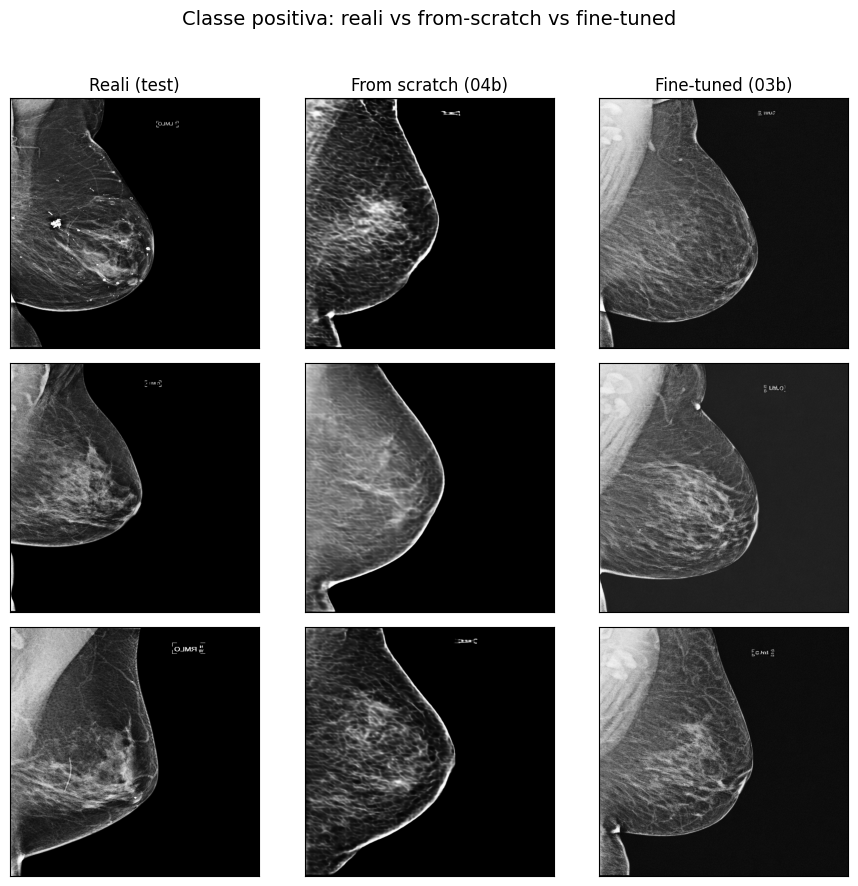

Salvato: /mnt/MammoDiffusion/MammoDiffusion/results/04c_Confronto_FromScratch_vs_FineTuned/plots/grid_real_vs_fromscratch_vs_finetuned_positive.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as PILImage

N_SAMPLES = 3


def first_image_paths(directory, n_samples):
    return sorted(Path(directory).glob("*.png"))[:n_samples]


positive_groups = {
    "Reali (test)": first_image_paths(REAL_DIRS["positive"], N_SAMPLES),
    "From scratch (04b)": first_image_paths(FROMSCRATCH_DIRS["positive"], N_SAMPLES),
    "Fine-tuned (03b)": first_image_paths(FINETUNED_DIRS["positive"], N_SAMPLES),
}

fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(9, 3 * N_SAMPLES))
for col, (group_name, paths) in enumerate(positive_groups.items()):
    for row, path in enumerate(paths):
        with PILImage.open(path) as image:
            axes[row, col].imshow(np.asarray(image.convert("L")), cmap="gray", vmin=0, vmax=255)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
    axes[0, col].set_title(group_name, fontsize=12)

fig.suptitle("Classe positiva: reali vs from-scratch vs fine-tuned", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.96))
output_path = RESULTS_PLOTS_DIR / "grid_real_vs_fromscratch_vs_finetuned_positive.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Salvato:", output_path)


## 4. Griglia compatta immagini positive per la slide D1

Questa versione 2x3 riprende solo due esempi per gruppo ed e' pensata per l'inserimento diretto in slide.

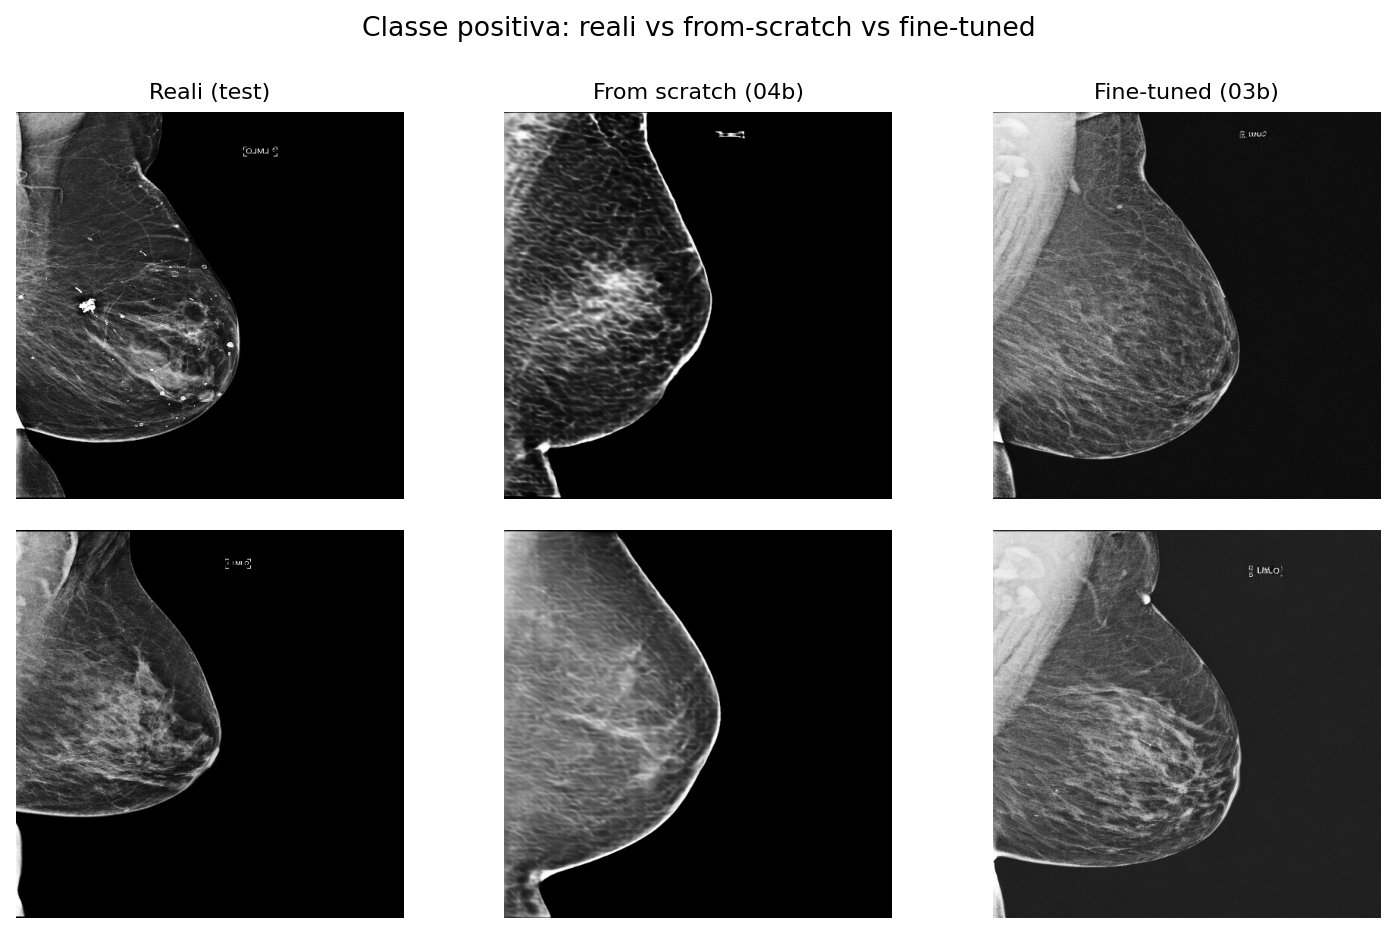

Salvato: /mnt/MammoDiffusion/MammoDiffusion/results/04c_Confronto_FromScratch_vs_FineTuned/plots/grid_real_vs_fromscratch_vs_finetuned_positive_slide_layout.png


In [4]:
SLIDE_IMAGE_SAMPLES = 2
slide_image_groups = {
    "Reali (test)": first_image_paths(REAL_DIRS["positive"], SLIDE_IMAGE_SAMPLES),
    "From scratch (04b)": first_image_paths(FROMSCRATCH_DIRS["positive"], SLIDE_IMAGE_SAMPLES),
    "Fine-tuned (03b)": first_image_paths(FINETUNED_DIRS["positive"], SLIDE_IMAGE_SAMPLES),
}

fig, axes = plt.subplots(SLIDE_IMAGE_SAMPLES, 3, figsize=(9.6, 6.0), dpi=160)
fig.patch.set_facecolor("white")
for col, (group_name, paths) in enumerate(slide_image_groups.items()):
    for row in range(SLIDE_IMAGE_SAMPLES):
        ax = axes[row, col]
        if row < len(paths):
            with PILImage.open(paths[row]) as image:
                ax.imshow(np.asarray(image.convert("L")), cmap="gray", vmin=0, vmax=255)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    axes[0, col].set_title(group_name, fontsize=10, pad=6)

fig.suptitle("Classe positiva: reali vs from-scratch vs fine-tuned", fontsize=12, y=0.98)
fig.subplots_adjust(left=0.04, right=0.96, bottom=0.04, top=0.88, wspace=0.12, hspace=0.08)
output_path = RESULTS_PLOTS_DIR / "grid_real_vs_fromscratch_vs_finetuned_positive_slide_layout.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)
print("Salvato:", output_path)

## 5. Metriche finali sul test set

Legge `final_test_metrics.json` (03b) e `final_filtered_vs_test.json` (04b), limitandosi alla **classe positiva** (tumorale): e' l'unica generata dal modello from-scratch ed e' la classe obiettivo dell'augmentation, quindi e' l'unico confronto realmente alla pari. Stesso backend di valutazione (`generative_evaluator.py`) e stesso riferimento reale (test set) per entrambi, quindi FID/IS/PRDC sono direttamente comparabili.

In [5]:
import json

import pandas as pd

with open(RESULTS_FT_DIR / "metrics" / "final_test_metrics.json", encoding="utf-8") as handle:
    ft_final = json.load(handle)

with open(RESULTS_FS_DIR / "metrics" / "final_filtered_vs_test.json", encoding="utf-8") as handle:
    fs_final = json.load(handle)

# Confronto limitato alla classe positiva (tumorale): e' l'unica generata dal
# modello from-scratch (04b) ed e' la classe obiettivo dell'augmentation.
final_rows = []

ft_metrics = ft_final["per_class"]["positive"]
final_rows.append({
    "pipeline": "Fine-tuned (03b)",
    "class": "positive",
    "FID": ft_metrics["FID"],
    "IS_mean": ft_metrics["IS_mean"],
    "IS_std": ft_metrics["IS_std"],
    "precision": ft_metrics["precision"],
    "recall": ft_metrics["recall"],
    "density": ft_metrics["density"],
    "coverage": ft_metrics["coverage"],
    "n_generated": ft_metrics["n_generated"],
    "n_real_reference": ft_metrics["n_real_reference"],
})

fs_metrics = fs_final["metrics"]
final_rows.append({
    "pipeline": "From scratch (04b)",
    "class": "positive",
    "FID": fs_metrics["FID"],
    "IS_mean": fs_metrics["IS_mean"],
    "IS_std": fs_metrics["IS_std"],
    "precision": fs_metrics["precision"],
    "recall": fs_metrics["recall"],
    "density": fs_metrics["density"],
    "coverage": fs_metrics["coverage"],
    "n_generated": fs_metrics["n_synthetic_filtered"],
    "n_real_reference": fs_metrics["n_real_test"],
})

df_final_metrics = pd.DataFrame(final_rows)
output_csv = RESULTS_METRICS_DIR / "final_test_metrics_comparison.csv"
df_final_metrics.to_csv(output_csv, index=False)
print("Salvato:", output_csv)
df_final_metrics

Salvato: /mnt/MammoDiffusion/MammoDiffusion/results/04c_Confronto_FromScratch_vs_FineTuned/metrics/final_test_metrics_comparison.csv


,pipeline,class,FID,IS_mean,IS_std,precision,recall,density,coverage,n_generated,n_real_reference
0,Fine-tuned (03b),positive,113.0254,2.4170,0.0738,0.6120,0.2740,0.3456,0.9726,1361,73
1,From scratch (04b),positive,154.5194,2.2751,0.1003,0.1132,0.0137,0.0531,0.4932,1361,73


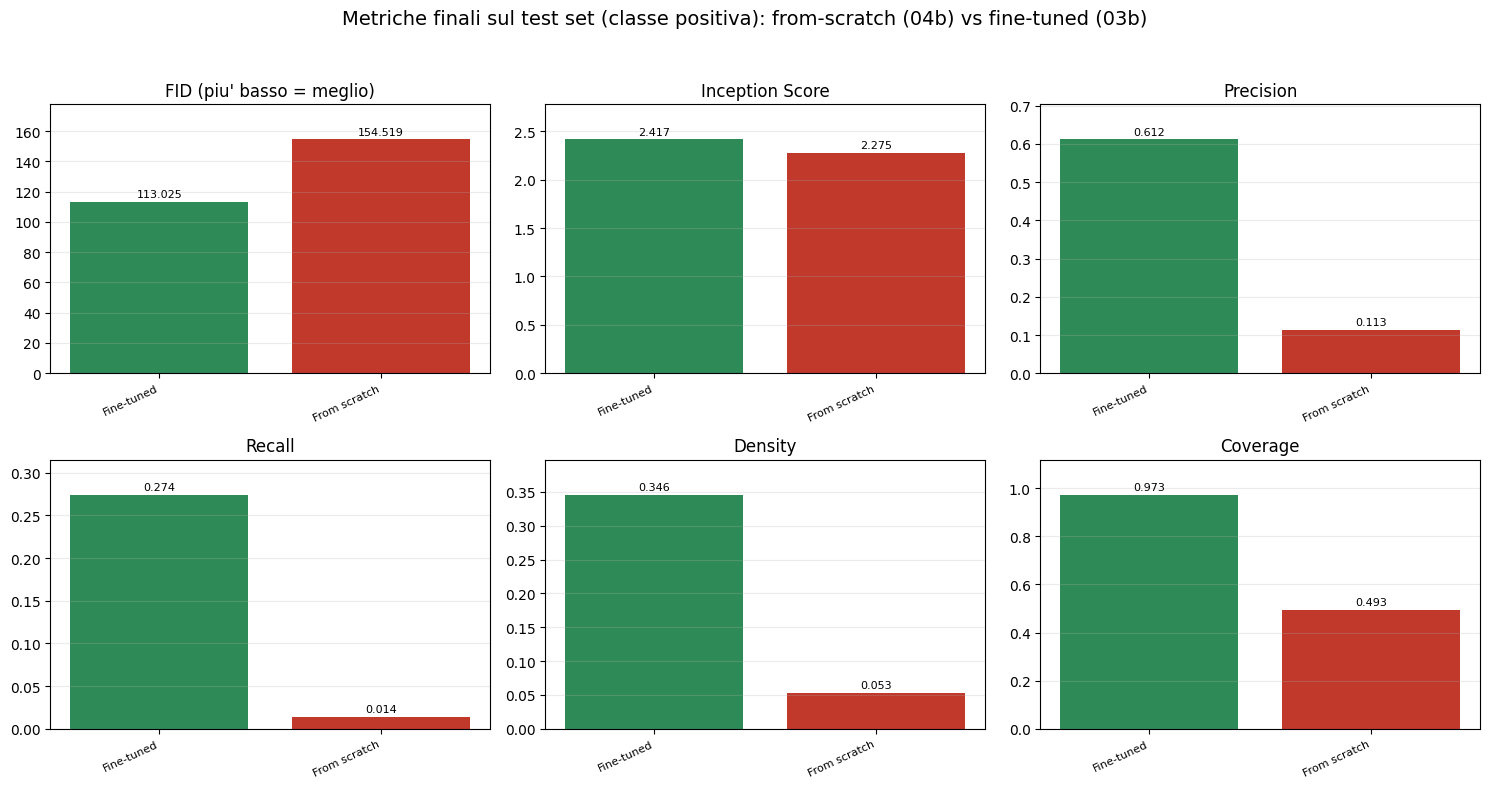

Salvato: /mnt/MammoDiffusion/MammoDiffusion/results/04c_Confronto_FromScratch_vs_FineTuned/plots/final_test_metrics_comparison.png


In [6]:
metric_specs = [
    ("FID", "FID (piu' basso = meglio)"),
    ("IS_mean", "Inception Score"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("density", "Density"),
    ("coverage", "Coverage"),
]

df_final_metrics["serie"] = df_final_metrics["pipeline"].str.replace(
    r"\s*\(0[34]b\)", "", regex=True
)
colors = {
    "Fine-tuned": "#2e8b57",
    "From scratch": "#c0392b",
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (column, title) in zip(axes.ravel(), metric_specs):
    bars = ax.bar(
        df_final_metrics["serie"],
        df_final_metrics[column],
        color=[colors.get(serie, "#888888") for serie in df_final_metrics["serie"]],
    )
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
    # Margine in alto cosi' le etichette delle barre non toccano il bordo del grafico
    top = max(df_final_metrics[column].max(), 0)
    ax.set_ylim(top=top * 1.15)
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Metriche finali sul test set (classe positiva): from-scratch (04b) vs fine-tuned (03b)", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.95))
output_path = RESULTS_PLOTS_DIR / "final_test_metrics_comparison.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Salvato:", output_path)

## 6. Figura compatta per la slide D1

Questa figura affianca, non sostituisce, il plot 2x3 della cella precedente.

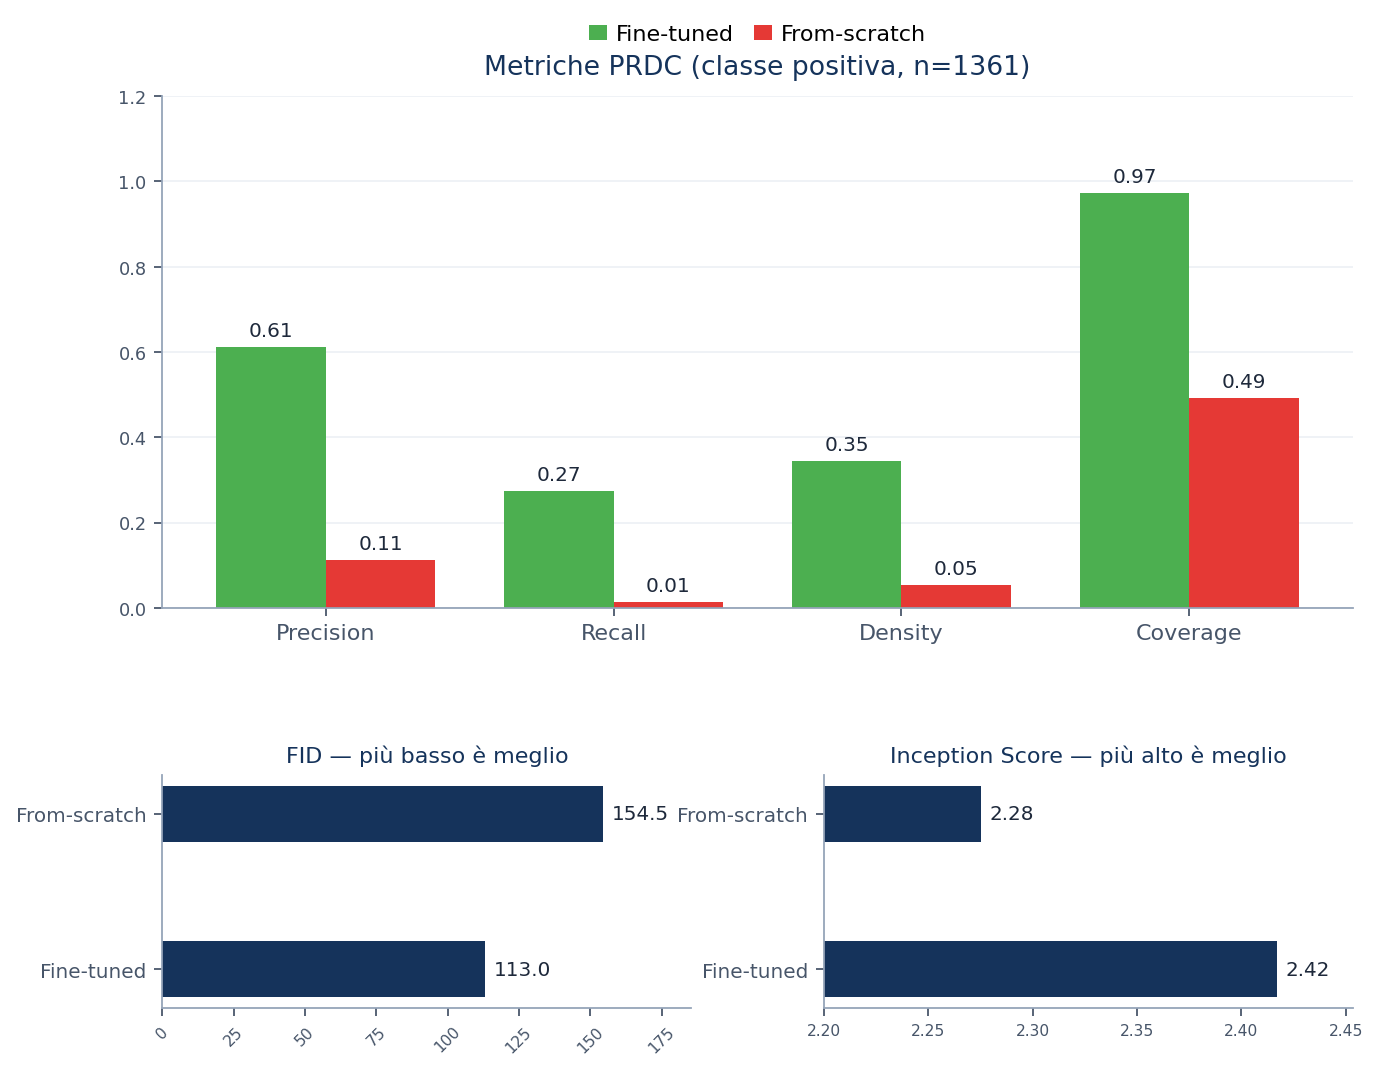

Salvato: /mnt/MammoDiffusion/MammoDiffusion/results/04c_Confronto_FromScratch_vs_FineTuned/plots/final_test_metrics_slide_layout.png


In [7]:
ft_color = "#4CAF50"
fs_color = "#E53935"
navy = "#15335B"
grid_color = "#E2E8F0"
bar_navy = "#15335B"
label_color = "#1E293B"
tick_color = "#475569"

plt.rcParams["font.family"] = "DejaVu Sans"

ft_row = df_final_metrics[df_final_metrics["pipeline"] == "Fine-tuned (03b)"].iloc[0]
fs_row = df_final_metrics[df_final_metrics["pipeline"] == "From scratch (04b)"].iloc[0]

fig = plt.figure(figsize=(9.6, 7.4), dpi=160)
fig.patch.set_facecolor("white")
gs = fig.add_gridspec(2, 2, height_ratios=[2.2, 1], hspace=0.45, wspace=0.25)

ax_prdc = fig.add_subplot(gs[0, :])
ax_fid = fig.add_subplot(gs[1, 0])
ax_is = fig.add_subplot(gs[1, 1])

def style_slide_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#94A3B8")
    ax.spines["bottom"].set_color("#94A3B8")
    ax.tick_params(colors=tick_color)

# Subplot A: metriche PRDC sulla classe positiva.
prdc_labels = ["Precision", "Recall", "Density", "Coverage"]
ft_values = np.array([
    ft_row["precision"], ft_row["recall"], ft_row["density"], ft_row["coverage"]
], dtype=float)
fs_values = np.array([
    fs_row["precision"], fs_row["recall"], fs_row["density"], fs_row["coverage"]
], dtype=float)

x = np.arange(len(prdc_labels))
width = 0.38
ft_bars = ax_prdc.bar(x - width / 2, ft_values, width, label="Fine-tuned", color=ft_color)
fs_bars = ax_prdc.bar(x + width / 2, fs_values, width, label="From-scratch", color=fs_color)
ax_prdc.bar_label(ft_bars, fmt="%.2f", padding=3, fontsize=9, color=label_color)
ax_prdc.bar_label(fs_bars, fmt="%.2f", padding=3, fontsize=9, color=label_color)
ax_prdc.set_title("Metriche PRDC (classe positiva, n=1361)", fontsize=12, color=navy, pad=10)
ax_prdc.set_xticks(x)
ax_prdc.set_xticklabels(prdc_labels, fontsize=10, color=tick_color)
ax_prdc.tick_params(axis="y", labelsize=8, colors=tick_color)
ax_prdc.set_ylim(0, 1.20)
ax_prdc.grid(axis="y", color=grid_color, alpha=0.6, linewidth=0.8)
ax_prdc.set_axisbelow(True)
ax_prdc.legend(
    fontsize=10,
    frameon=False,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.18),
    handlelength=0.8,
    handletextpad=0.4,
    columnspacing=0.9,
)
style_slide_axis(ax_prdc)

# Subplot B: FID, con scala assoluta e barre orizzontali compatte.
fid_values = [float(fs_row["FID"]), float(ft_row["FID"])]
fid_bars = ax_fid.barh([1, 0], fid_values, color=bar_navy, height=0.36)
ax_fid.set_title("FID \u2014 pi\u00f9 basso \u00e8 meglio", fontsize=10, color=navy, pad=6)
ax_fid.set_yticks([0, 1])
ax_fid.set_yticklabels(["Fine-tuned", "From-scratch"], fontsize=9, color=tick_color)
ax_fid.bar_label(fid_bars, fmt="%.1f", padding=4, fontsize=9, color=label_color)
ax_fid.set_xlim(0, max(fid_values) * 1.20)
ax_fid.tick_params(axis="x", labelsize=7, colors=tick_color, rotation=45)
ax_fid.grid(False)
style_slide_axis(ax_fid)

# Subplot C: Inception Score, zoomato sul range utile per la slide.
is_values = [float(fs_row["IS_mean"]), float(ft_row["IS_mean"])]
is_bars = ax_is.barh([1, 0], is_values, color=bar_navy, height=0.36)
ax_is.set_title("Inception Score \u2014 pi\u00f9 alto \u00e8 meglio", fontsize=10, color=navy, pad=6)
ax_is.set_yticks([0, 1])
ax_is.set_yticklabels(["Fine-tuned", "From-scratch"], fontsize=9, color=tick_color)
ax_is.bar_label(is_bars, fmt="%.2f", padding=4, fontsize=9, color=label_color)
ax_is.set_xlim(2.20, max(is_values) * 1.015)
ax_is.tick_params(axis="x", labelsize=7, colors=tick_color)
ax_is.grid(False)
style_slide_axis(ax_is)

output_path = RESULTS_PLOTS_DIR / "final_test_metrics_slide_layout.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)
print("Salvato:", output_path)

## 7. Variazione filtro vs RAW per la slide D1

Questa figura compatta riassume il delta orientato al miglioramento tra campioni raw e filtrati.

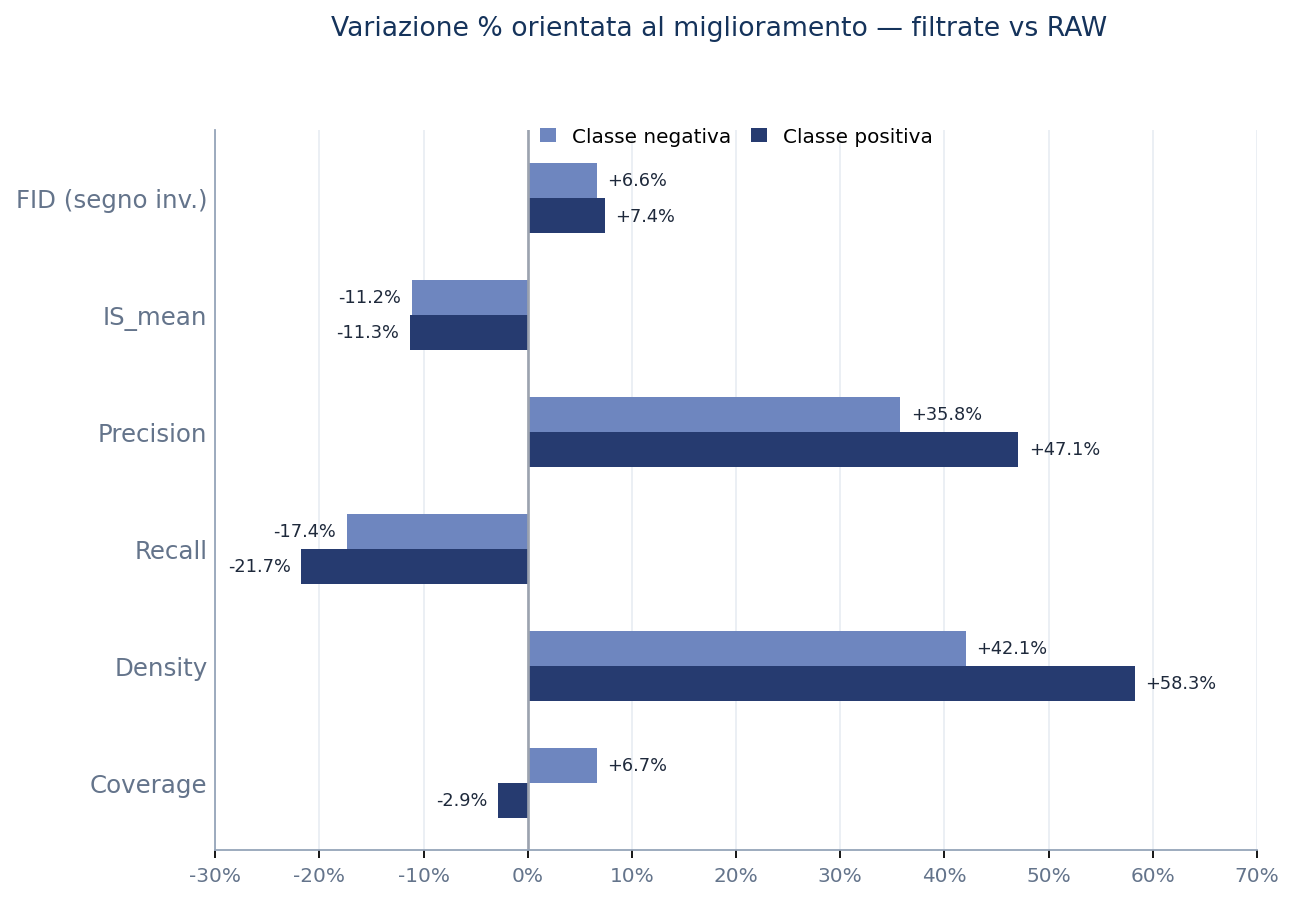

Salvato: /mnt/MammoDiffusion/MammoDiffusion/results/04c_Confronto_FromScratch_vs_FineTuned/plots/filter_oriented_percent_delta_slide_layout.png


In [8]:
filter_metrics_path = RESULTS_FT_DIR / "metrics" / "validation_comparison_100_steps_raw_matched_vs_filtered.csv"
df_filter_metrics = pd.read_csv(filter_metrics_path)
df_filter_metrics = df_filter_metrics[df_filter_metrics["comparison_role"] == "filter_comparison"]

metric_order = ["FID", "IS_mean", "precision", "recall", "density", "coverage"]
metric_labels = ["FID (segno inv.)", "IS_mean", "Precision", "Recall", "Density", "Coverage"]
classes = ["negative", "positive"]
class_labels = {
    "negative": "Classe negativa",
    "positive": "Classe positiva",
}
class_colors = {
    "negative": "#6E86BF",
    "positive": "#263B70",
}

delta_by_class = {}
for class_name in classes:
    raw_row = df_filter_metrics[
        (df_filter_metrics["class"] == class_name)
        & (df_filter_metrics["stage"] == "raw_matched")
    ].iloc[0]
    filtered_row = df_filter_metrics[
        (df_filter_metrics["class"] == class_name)
        & (df_filter_metrics["stage"] == "filtered")
    ].iloc[0]

    deltas = []
    for metric in metric_order:
        raw_value = float(raw_row[metric])
        filtered_value = float(filtered_row[metric])
        if metric == "FID":
            delta = (raw_value - filtered_value) / raw_value * 100
        else:
            delta = (filtered_value - raw_value) / raw_value * 100
        deltas.append(delta)
    delta_by_class[class_name] = np.array(deltas, dtype=float)

fig, ax = plt.subplots(figsize=(8.4, 6.0), dpi=160)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

y = np.arange(len(metric_labels))
bar_height = 0.30
bars_negative = ax.barh(
    y - bar_height / 2,
    delta_by_class["negative"],
    height=bar_height,
    color=class_colors["negative"],
    label=class_labels["negative"],
)
bars_positive = ax.barh(
    y + bar_height / 2,
    delta_by_class["positive"],
    height=bar_height,
    color=class_colors["positive"],
    label=class_labels["positive"],
)

fig.suptitle(
    "Variazione % orientata al miglioramento \u2014 filtrate vs RAW",
    fontsize=12,
    color=navy,
    y=0.98,
)
ax.set_yticks(y)
ax.set_yticklabels(metric_labels, fontsize=11, color="#64748B")
ax.invert_yaxis()
ax.set_xlim(-30, 70)
ax.set_xticks(np.arange(-30, 71, 10))
ax.set_xticklabels([f"{tick:.0f}%" for tick in np.arange(-30, 71, 10)], fontsize=9, color="#64748B")
ax.axvline(0, color="#9CA3AF", linewidth=1.2)
ax.grid(axis="x", color=grid_color, alpha=0.75, linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=2,
    frameon=False,
    fontsize=9,
    handlelength=0.8,
    columnspacing=1.0,
)

for bars in [bars_negative, bars_positive]:
    for bar in bars:
        value = bar.get_width()
        if value >= 0:
            x_text = value + 1.0
            ha = "left"
        else:
            x_text = value - 1.0
            ha = "right"
        ax.text(
            x_text,
            bar.get_y() + bar.get_height() / 2,
            f"{value:+.1f}%",
            va="center",
            ha=ha,
            fontsize=8,
            color=label_color,
        )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#94A3B8")
ax.spines["bottom"].set_color("#94A3B8")
ax.tick_params(axis="y", length=0)
fig.subplots_adjust(top=0.86)

output_path = RESULTS_PLOTS_DIR / "filter_oriented_percent_delta_slide_layout.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)
print("Salvato:", output_path)

---

# Parte C - Archivio: VAE zero vs SD-VAE vs fine-tuned (celle con plot storici)

Contenuto originale di `comparisons/diffusers/00x_vae_comparison.ipynb`.
Stessa nota di Parte B: celle con plot preservati, non pensate per essere
rieseguite.


# Confronto VAE: custom from-scratch vs SD-VAE vs fine-tuned

Notebook di sola analisi. Confronta:
- diffusore from-scratch con VAE addestrato da zero (`04b`);
- diffusore from-scratch con VAE preaddestrato Stable Diffusion (`04b2`);
- diffusore Stable Diffusion fine-tuned (`03b`).


## 1. Percorsi


In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image as PILImage

PROJECT_NAME = "MammoDiffusion"
PROJECT_ROOT_OVERRIDE = None


def find_project_root(project_name=PROJECT_NAME, override=PROJECT_ROOT_OVERRIDE):
    if override is not None:
        root = Path(override).expanduser().resolve()
        if not root.exists():
            raise FileNotFoundError(root)
        return root
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if candidate.name == project_name:
            return candidate
        has_notebooks = (candidate / "notebooks").exists() or (candidate / "notebooks").exists()
        if ((candidate / "data").exists() and has_notebooks) or ((candidate / ".git").exists() and has_notebooks):
            return candidate
    raise FileNotFoundError("Root MammoDiffusion non trovata.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
SYNTHETIC_DIR = DATA_DIR / "synthetic"
DATA_PROCESSED_DIR = DATA_DIR / "processed"

RESULTS_FT_DIR = PROJECT_ROOT / "results" / "diffusers/02_sd21_filtered_100steps"
RESULTS_CUSTOM_DIR = PROJECT_ROOT / "results" / "diffusers/06_ldm_extra1361_fromscratch"
RESULTS_SDVAE_DIR = PROJECT_ROOT / "results" / "diffusers/07_ldm_sdvae_extra1361"
EXPERIMENT_CUSTOM_DIR = PROJECT_ROOT / "experiments" / "diffusers/06_ldm_extra1361_fromscratch"
EXPERIMENT_SDVAE_DIR = PROJECT_ROOT / "experiments" / "diffusers/07_ldm_sdvae_extra1361"

RESULTS_STAGE_NAME = "comparisons/diffusers/00x_vae_comparison"
RESULTS_DIR = PROJECT_ROOT / "results" / RESULTS_STAGE_NAME
RESULTS_PLOTS_DIR = RESULTS_DIR / "plots"
RESULTS_METRICS_DIR = RESULTS_DIR / "metrics"
for directory in [RESULTS_PLOTS_DIR, RESULTS_METRICS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_DIR :", RESULTS_DIR)


PROJECT_ROOT: /home/fede/Documenti/MammoDiffusion
RESULTS_DIR : /home/fede/Documenti/MammoDiffusion/results/04c1_Confronto_VAEZero_vs_SDVAE_vs_FineTuned


## 2. Caricamento metriche finali


In [2]:
METRIC_COLUMNS = ["FID", "IS_mean", "IS_std", "precision", "recall", "density", "coverage"]


def read_json(path):
    path = Path(path)
    if not path.exists():
        print("MISSING:", path)
        return None
    with open(path, encoding="utf-8") as handle:
        return json.load(handle)


def row_from_metrics(pipeline, class_name, metrics, source_path):
    if metrics is None:
        return None
    return {
        "pipeline": pipeline,
        "class": class_name,
        "source_path": str(source_path),
        "FID": float(metrics.get("FID", np.nan)),
        "IS_mean": float(metrics.get("IS_mean", np.nan)),
        "IS_std": float(metrics.get("IS_std", np.nan)),
        "precision": float(metrics.get("precision", np.nan)),
        "recall": float(metrics.get("recall", np.nan)),
        "density": float(metrics.get("density", np.nan)),
        "coverage": float(metrics.get("coverage", np.nan)),
        "n_generated": int(metrics.get("n_generated", metrics.get("n_synthetic_filtered", 0))),
        "n_real_reference": int(metrics.get("n_real_reference", metrics.get("n_real_test", 0))),
    }


rows = []

# Fine-tuned SD2.1: schema per_class.
ft_path = RESULTS_FT_DIR / "metrics" / "final_test_metrics.json"
ft_payload = read_json(ft_path)
if ft_payload:
    for class_name in ["positive", "negative"]:
        rows.append(row_from_metrics(
            "FineTuned_SD2.1",
            class_name,
            ft_payload["per_class"].get(class_name),
            ft_path,
        ))

# From-scratch custom VAE: positivo canonico, negativo se prodotto dall'estensione 04b.
custom_pos_path = RESULTS_CUSTOM_DIR / "metrics" / "positive" / "final_filtered_vs_test.json"
custom_pos = read_json(custom_pos_path)
if custom_pos:
    rows.append(row_from_metrics(
        "FromScratch_CustomVAE",
        "positive",
        custom_pos.get("metrics"),
        custom_pos_path,
    ))
custom_neg_candidates = [
    RESULTS_CUSTOM_DIR / "metrics" / "negative" / "final_filtered_vs_test.json",
]
for candidate in custom_neg_candidates:
    payload = read_json(candidate)
    if payload:
        rows.append(row_from_metrics("FromScratch_CustomVAE", "negative", payload.get("metrics"), candidate))
        break

# From-scratch SD-VAE: metriche positive e negative separate per classe del nuovo esperimento.
sdvae_pos_path = RESULTS_SDVAE_DIR / "metrics" / "positive" / "final_filtered_vs_test.json"
sdvae_pos = read_json(sdvae_pos_path)
if sdvae_pos:
    rows.append(row_from_metrics(
        "FromScratch_SD_VAE",
        "positive",
        sdvae_pos.get("metrics"),
        sdvae_pos_path,
    ))
sdvae_neg_candidates = [
    RESULTS_SDVAE_DIR / "metrics" / "negative" / "final_filtered_vs_test.json",
]
for candidate in sdvae_neg_candidates:
    payload = read_json(candidate)
    if payload:
        rows.append(row_from_metrics("FromScratch_SD_VAE", "negative", payload.get("metrics"), candidate))
        break

rows = [row for row in rows if row is not None]
if not rows:
    raise RuntimeError("Nessuna metrica trovata. Esegui prima 03b, 04b e 04b2.")

df_long = pd.DataFrame(rows)
long_path = RESULTS_METRICS_DIR / "vae_metric_comparison_long.csv"
df_long.to_csv(long_path, index=False)
print("Salvato:", long_path)
df_long


MISSING: /home/fede/Documenti/MammoDiffusion/experiments/20260619_ldm_extra1361/evaluation_negative/final_filtered_vs_test.json
MISSING: /home/fede/Documenti/MammoDiffusion/data/synthetic/fromscratch/test_outputs_smoke/final_filtered_vs_test.json
Salvato: /home/fede/Documenti/MammoDiffusion/results/04c1_Confronto_VAEZero_vs_SDVAE_vs_FineTuned/metrics/vae_metric_comparison_long.csv


,pipeline,class,source_path,FID,IS_mean,IS_std,precision,recall,density,coverage,n_generated,n_real_reference
0,FineTuned_SD2.1,positive,/home/fede/Documenti/MammoDiffusion/results/03...,113.0254,2.4159,0.1138,0.6120,0.2740,0.3456,0.9726,1361,73
1,FineTuned_SD2.1,negative,/home/fede/Documenti/MammoDiffusion/results/03...,114.1593,2.3891,0.1175,0.4717,0.2055,0.2178,0.8767,1361,73
2,FromScratch_CustomVAE,positive,/home/fede/Documenti/MammoDiffusion/results/04...,154.5427,2.2722,0.0963,0.1139,0.0137,0.0534,0.4932,1361,73
3,FromScratch_SD_VAE,positive,/home/fede/Documenti/MammoDiffusion/results/04...,127.1515,2.3761,0.0957,0.2697,0.1096,0.1398,0.6164,1361,73
4,FromScratch_SD_VAE,negative,/home/fede/Documenti/MammoDiffusion/experiment...,93.9168,2.6066,0.1147,0.3159,0.1123,0.1558,0.2548,1361,365


## 3. Medie per pipeline e classi disponibili


In [3]:
summary_rows = []
for pipeline, group in df_long.groupby("pipeline"):
    row = {"pipeline": pipeline, "class": "available_average", "n_classes": int(group["class"].nunique())}
    for metric in METRIC_COLUMNS:
        row[metric] = float(group[metric].mean())
    row["n_generated"] = int(group["n_generated"].sum())
    row["n_real_reference"] = int(group["n_real_reference"].mean())
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
summary_path = RESULTS_METRICS_DIR / "vae_metric_comparison_summary.csv"
df_summary.to_csv(summary_path, index=False)
print("Salvato:", summary_path)
df_summary


Salvato: /home/fede/Documenti/MammoDiffusion/results/04c1_Confronto_VAEZero_vs_SDVAE_vs_FineTuned/metrics/vae_metric_comparison_summary.csv


,pipeline,class,n_classes,FID,IS_mean,IS_std,precision,recall,density,coverage,n_generated,n_real_reference
0,FineTuned_SD2.1,available_average,2,113.59235,2.40250,0.11565,0.54185,0.23975,0.2817,0.92465,2722,73
1,FromScratch_CustomVAE,available_average,1,154.54270,2.27220,0.09630,0.11390,0.01370,0.0534,0.49320,1361,73
2,FromScratch_SD_VAE,available_average,2,110.53415,2.49135,0.10520,0.29280,0.11095,0.1478,0.43560,2722,219


## 4. Migliore from-scratch vs fine-tuned


In [4]:
HIGHER_IS_BETTER = {
    "FID": False,
    "IS_mean": True,
    "IS_std": False,
    "precision": True,
    "recall": True,
    "density": True,
    "coverage": True,
}

comparison_rows = []
for class_name in sorted(df_long["class"].unique()):
    class_df = df_long[df_long["class"] == class_name]
    ft_df = class_df[class_df["pipeline"] == "FineTuned_SD2.1"]
    fs_df = class_df[class_df["pipeline"].isin(["FromScratch_CustomVAE", "FromScratch_SD_VAE"])]
    if ft_df.empty or fs_df.empty:
        continue
    ft_row = ft_df.iloc[0]
    for metric, higher in HIGHER_IS_BETTER.items():
        fs_valid = fs_df.dropna(subset=[metric])
        if fs_valid.empty or pd.isna(ft_row[metric]):
            continue
        if higher:
            best_idx = fs_valid[metric].idxmax()
            winner_value = max(float(fs_valid.loc[best_idx, metric]), float(ft_row[metric]))
            overall_winner = fs_valid.loc[best_idx, "pipeline"] if float(fs_valid.loc[best_idx, metric]) >= float(ft_row[metric]) else "FineTuned_SD2.1"
        else:
            best_idx = fs_valid[metric].idxmin()
            winner_value = min(float(fs_valid.loc[best_idx, metric]), float(ft_row[metric]))
            overall_winner = fs_valid.loc[best_idx, "pipeline"] if float(fs_valid.loc[best_idx, metric]) <= float(ft_row[metric]) else "FineTuned_SD2.1"
        comparison_rows.append({
            "class": class_name,
            "metric": metric,
            "higher_is_better": higher,
            "best_fromscratch_pipeline": fs_valid.loc[best_idx, "pipeline"],
            "best_fromscratch_value": float(fs_valid.loc[best_idx, metric]),
            "fine_tuned_value": float(ft_row[metric]),
            "overall_winner": overall_winner,
            "overall_winner_value": winner_value,
        })

df_best = pd.DataFrame(comparison_rows)
best_path = RESULTS_METRICS_DIR / "best_fromscratch_vs_finetuned.csv"
df_best.to_csv(best_path, index=False)
print("Salvato:", best_path)
df_best


Salvato: /home/fede/Documenti/MammoDiffusion/results/04c1_Confronto_VAEZero_vs_SDVAE_vs_FineTuned/metrics/best_fromscratch_vs_finetuned.csv


,class,metric,higher_is_better,best_fromscratch_pipeline,best_fromscratch_value,fine_tuned_value,overall_winner,overall_winner_value
0,negative,FID,False,FromScratch_SD_VAE,93.9168,114.1593,FromScratch_SD_VAE,93.9168
1,negative,IS_mean,True,FromScratch_SD_VAE,2.6066,2.3891,FromScratch_SD_VAE,2.6066
2,negative,IS_std,False,FromScratch_SD_VAE,0.1147,0.1175,FromScratch_SD_VAE,0.1147
3,negative,precision,True,FromScratch_SD_VAE,0.3159,0.4717,FineTuned_SD2.1,0.4717
4,negative,recall,True,FromScratch_SD_VAE,0.1123,0.2055,FineTuned_SD2.1,0.2055
5,negative,density,True,FromScratch_SD_VAE,0.1558,0.2178,FineTuned_SD2.1,0.2178
6,negative,coverage,True,FromScratch_SD_VAE,0.2548,0.8767,FineTuned_SD2.1,0.8767
7,positive,FID,False,FromScratch_SD_VAE,127.1515,113.0254,FineTuned_SD2.1,113.0254
8,positive,IS_mean,True,FromScratch_SD_VAE,2.3761,2.4159,FineTuned_SD2.1,2.4159
9,positive,IS_std,False,FromScratch_SD_VAE,0.0957,0.1138,FromScratch_SD_VAE,0.0957


## 5. Grafici metriche per classe


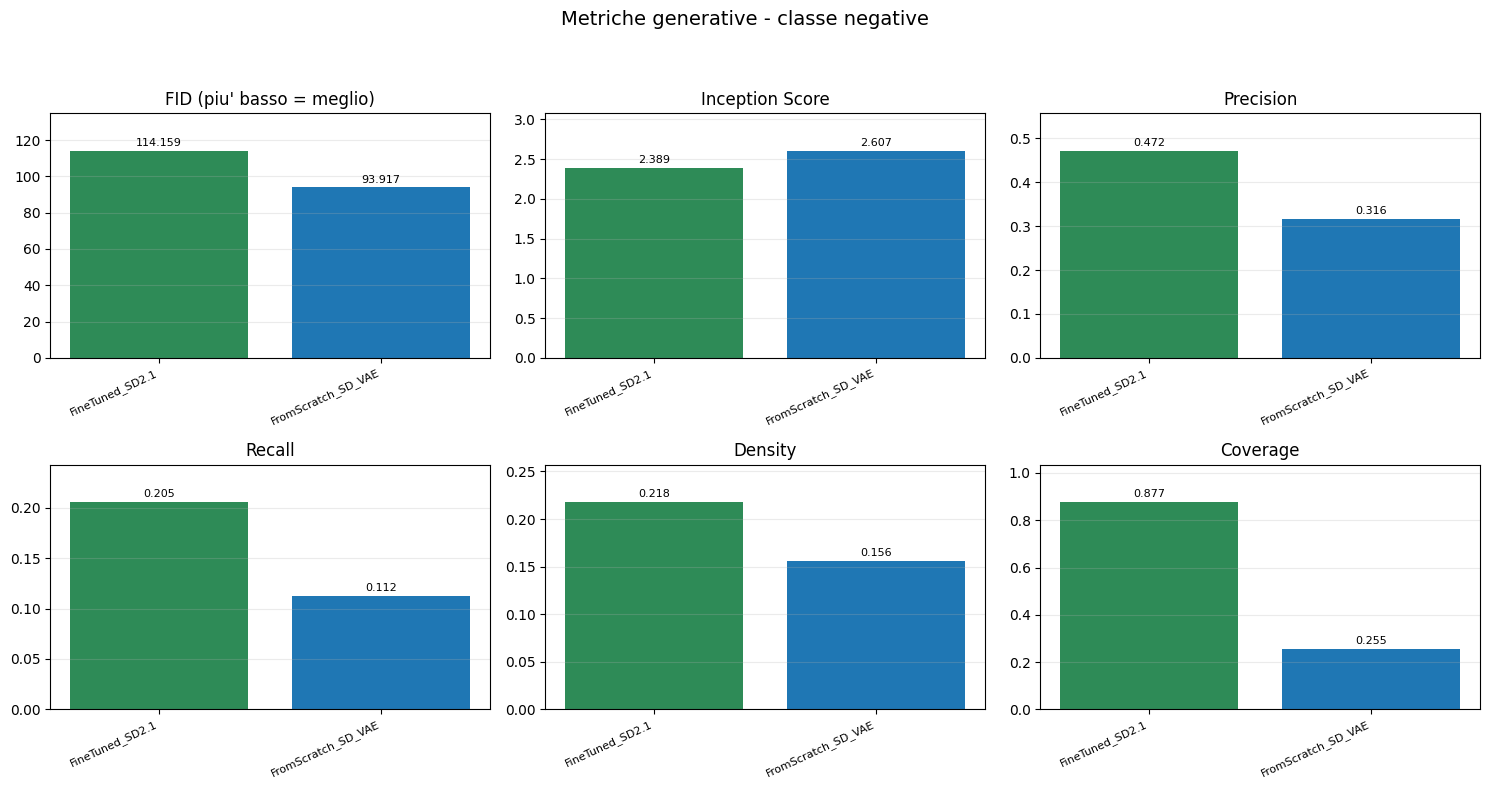

Salvato: /home/fede/Documenti/MammoDiffusion/results/04c1_Confronto_VAEZero_vs_SDVAE_vs_FineTuned/plots/metrics_by_pipeline_negative.png


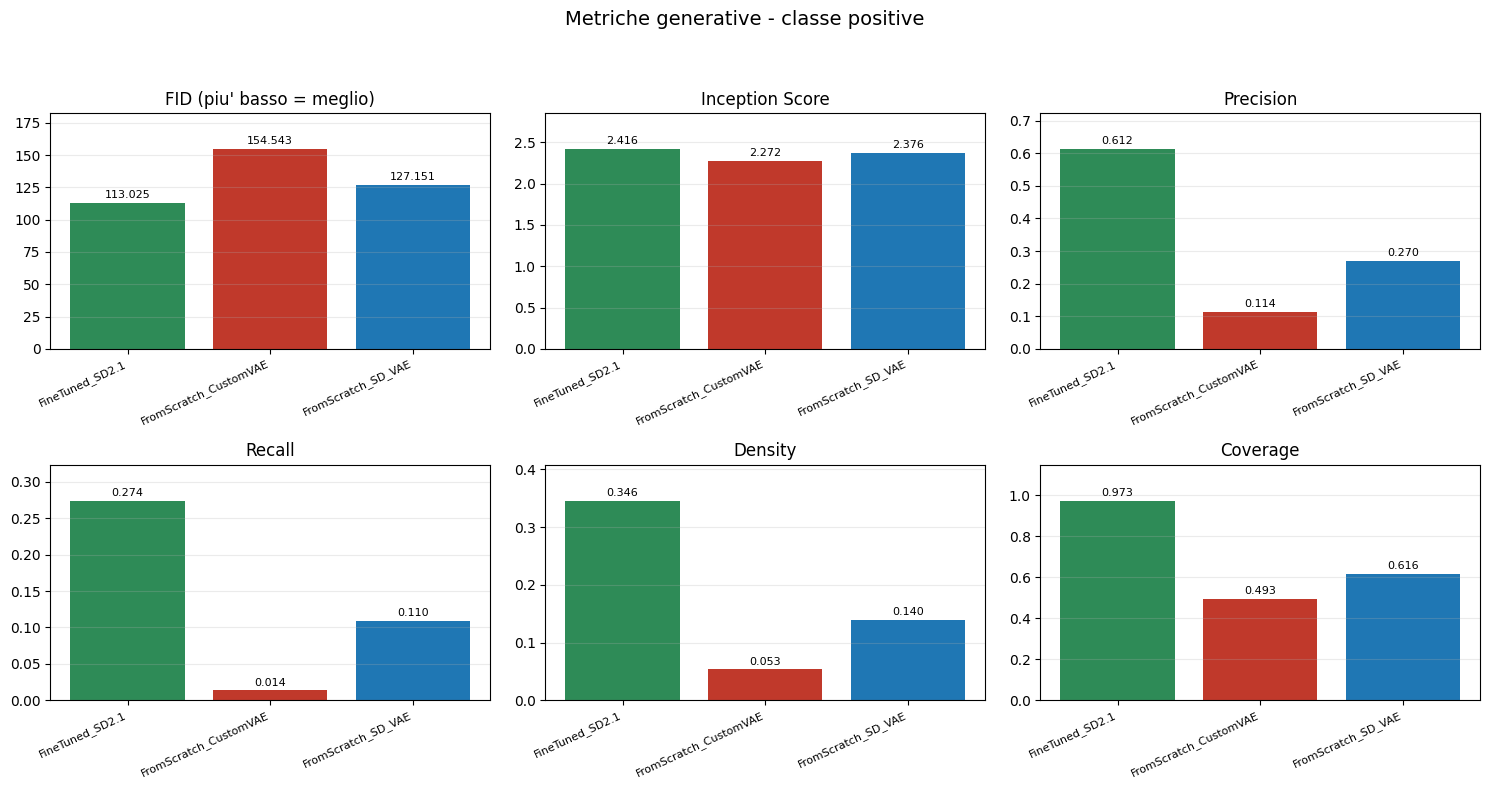

Salvato: /home/fede/Documenti/MammoDiffusion/results/04c1_Confronto_VAEZero_vs_SDVAE_vs_FineTuned/plots/metrics_by_pipeline_positive.png


In [5]:
PLOT_COLORS = {
    "FineTuned_SD2.1": "#2e8b57",
    "FromScratch_CustomVAE": "#c0392b",
    "FromScratch_SD_VAE": "#1f77b4",
}

metric_specs = [
    ("FID", "FID (piu' basso = meglio)"),
    ("IS_mean", "Inception Score"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("density", "Density"),
    ("coverage", "Coverage"),
]

for class_name, class_df in df_long.groupby("class"):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, (metric, title) in zip(axes.ravel(), metric_specs):
        plot_df = class_df.dropna(subset=[metric])
        bars = ax.bar(
            plot_df["pipeline"],
            plot_df[metric],
            color=[PLOT_COLORS.get(p, "#888888") for p in plot_df["pipeline"]],
        )
        ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
        top = max(float(plot_df[metric].max()), 0)
        ax.set_ylim(top=top * 1.18 if top > 0 else 1)
        ax.set_title(title)
        ax.grid(axis="y", alpha=0.25)
        plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)
    fig.suptitle(f"Metriche generative - classe {class_name}", fontsize=14)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    out_path = RESULTS_PLOTS_DIR / f"metrics_by_pipeline_{class_name}.png"
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Salvato:", out_path)


## 6. Radar PRDC


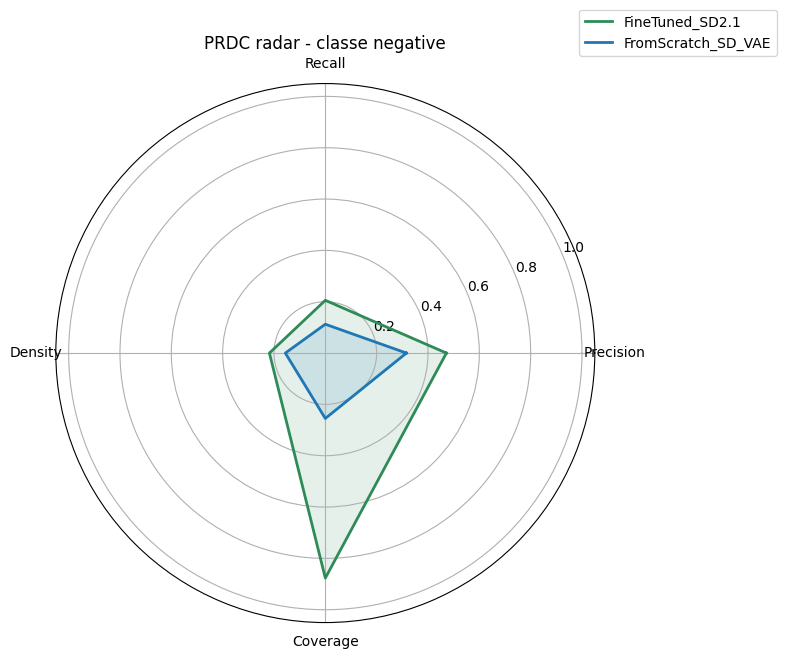

Salvato: /home/fede/Documenti/MammoDiffusion/results/04c1_Confronto_VAEZero_vs_SDVAE_vs_FineTuned/plots/prdc_radar_negative.png


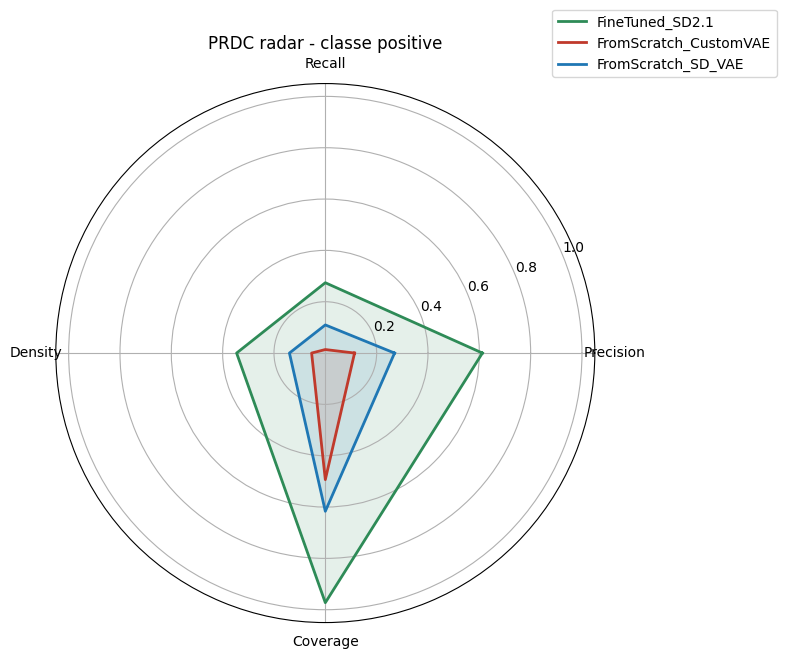

Salvato: /home/fede/Documenti/MammoDiffusion/results/04c1_Confronto_VAEZero_vs_SDVAE_vs_FineTuned/plots/prdc_radar_positive.png


In [6]:
radar_metrics = ["precision", "recall", "density", "coverage"]
for class_name, class_df in df_long.groupby("class"):
    angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})
    for _, row in class_df.iterrows():
        values = [float(row[m]) if not pd.isna(row[m]) else 0.0 for m in radar_metrics]
        values += values[:1]
        ax.plot(angles, values, label=row["pipeline"], color=PLOT_COLORS.get(row["pipeline"], "#888888"), linewidth=2)
        ax.fill(angles, values, alpha=0.12, color=PLOT_COLORS.get(row["pipeline"], "#888888"))
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(["Precision", "Recall", "Density", "Coverage"])
    ax.set_ylim(0, 1.05)
    ax.set_title(f"PRDC radar - classe {class_name}")
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
    out_path = RESULTS_PLOTS_DIR / f"prdc_radar_{class_name}.png"
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Salvato:", out_path)


## 7. Griglia qualitativa


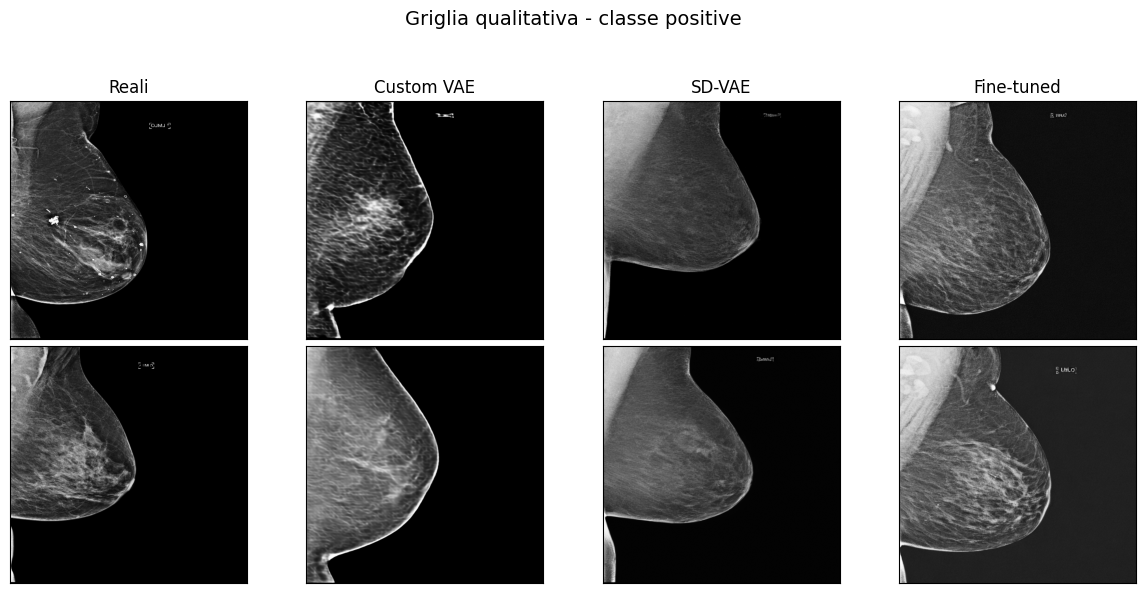

Salvato: /home/fede/Documenti/MammoDiffusion/results/04c1_Confronto_VAEZero_vs_SDVAE_vs_FineTuned/plots/qualitative_grid_positive.png


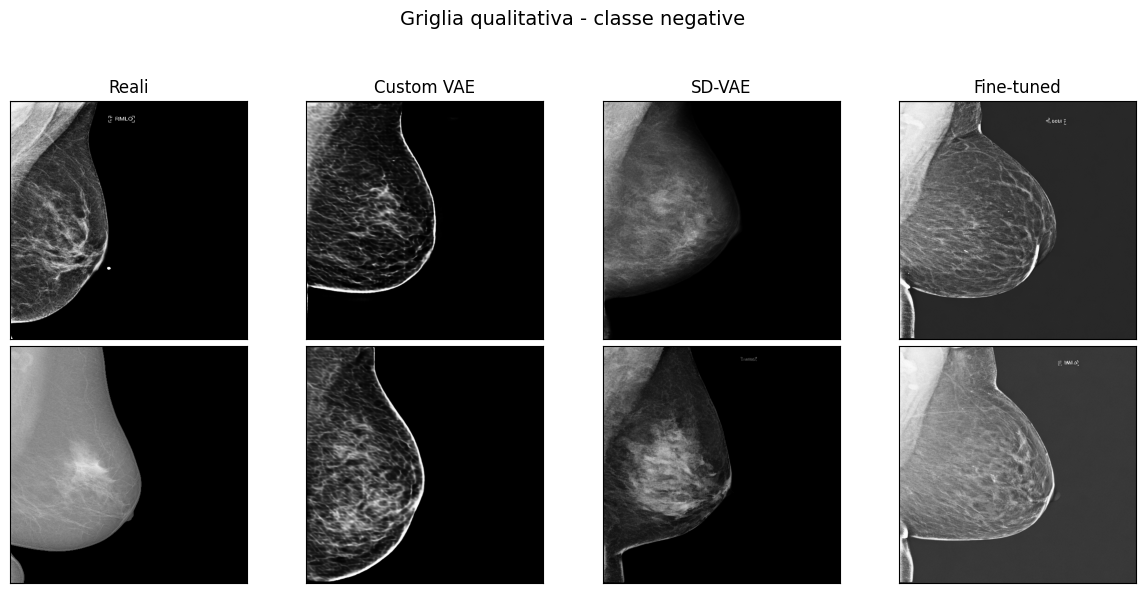

Salvato: /home/fede/Documenti/MammoDiffusion/results/04c1_Confronto_VAEZero_vs_SDVAE_vs_FineTuned/plots/qualitative_grid_negative.png


In [7]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg"}


def first_paths(directory, n=2):
    directory = Path(directory)
    if not directory.is_dir():
        return []
    return sorted(p for p in directory.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)[:n]


groups = {
    "Reali": {
        "positive": DATA_PROCESSED_DIR / "test" / "1",
        "negative": DATA_PROCESSED_DIR / "test" / "0",
    },
    "Custom VAE": {
        "positive": SYNTHETIC_DIR / "fromscratch" / "positive",
        "negative": SYNTHETIC_DIR / "fromscratch" / "negative",
    },
    "SD-VAE": {
        "positive": SYNTHETIC_DIR / "fromscratch_new" / "positive",
        "negative": SYNTHETIC_DIR / "fromscratch_new" / "negative",
    },
    "Fine-tuned": {
        "positive": SYNTHETIC_DIR / "fine_tuned" / "positive",
        "negative": SYNTHETIC_DIR / "fine_tuned" / "negative",
    },
}

for class_name in ["positive", "negative"]:
    selected = {name: first_paths(paths[class_name], n=2) for name, paths in groups.items()}
    n_rows = 2
    n_cols = len(groups)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    for col, (group_name, paths) in enumerate(selected.items()):
        for row in range(n_rows):
            ax = axes[row, col]
            if row < len(paths):
                with PILImage.open(paths[row]) as image:
                    ax.imshow(np.asarray(image.convert("L")), cmap="gray", vmin=0, vmax=255)
            ax.set_xticks([])
            ax.set_yticks([])
            if row == 0:
                ax.set_title(group_name)
    fig.suptitle(f"Griglia qualitativa - classe {class_name}", fontsize=14)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    out_path = RESULTS_PLOTS_DIR / f"qualitative_grid_{class_name}.png"
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Salvato:", out_path)


# Parte D - Confronto completo G01-G08 (v2)

# PART_D_FULL_G01_G08_V1

Estende sistematicamente il confronto a tutti gli otto generatori registrati in `configs/final_generator_registry.json`, tramite `generator_comparison_analysis.py`. Le Parti A/B/C restano l'archivio storico e non vengono modificate.

In [1]:
from pathlib import Path
import json, sys

def find_project_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "configs/final_generator_registry.json").is_file():
            return candidate
    raise FileNotFoundError("Project root not found")

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "notebooks/utility"))

import generator_comparison_analysis as gca
import matplotlib.pyplot as plt

tables = gca.write_outputs(PROJECT_ROOT)
for name, rows in tables.items():
    print(f"{name}: {len(rows)} righe -> results/generator_comparison/tables/{name}.json")


positive_class_comparison: 8 righe -> results/generator_comparison/tables/positive_class_comparison.json
two_class_comparison: 7 righe -> results/generator_comparison/tables/two_class_comparison.json
ablation_comparison: 5 righe -> results/generator_comparison/tables/ablation_comparison.json
sampling_ablation: 4 righe -> results/generator_comparison/tables/sampling_ablation.json
final_comparison: 5 righe -> results/generator_comparison/tables/final_comparison.json


## D.1 Confronto classe positiva (8/8 generatori) — spec 12.1

In [2]:

pos = tables["positive_class_comparison"]
for row in pos:
    fid = row.get("FID")
    print(f"{row['generator_id']:35s} FID={fid if fid is not None else 'N/D':>10} n_generated={row.get('n_generated')}")


01_sd21_baseline_50steps            FID=       N/D n_generated=None
02_sd21_filtered_100steps           FID=  113.0254 n_generated=1361
03_sd21_vae_finetuned               FID=   99.2599 n_generated=1361
04_sd21_lora                        FID=  145.0826 n_generated=1361
05_ldm_basic_fromscratch            FID=  166.8829 n_generated=1361
06_ldm_extra1361_fromscratch        FID=  154.5427 n_generated=1361
07_ldm_sdvae_extra1361              FID=  127.1515 n_generated=1361
08_ldm_v3_sdvae_fromscratch         FID=  113.5512 n_generated=1361


## D.2 Confronto due classi (solo generatori two-class) — spec 12.2

Un generatore con metriche incomplete per una classe resta con `status=incomplete_metrics` ed e' escluso dalla media: non viene mai mostrato un FID medio calcolato su una sola classe.

generatori con confronto due-classi completo: 4
generatori con metriche incomplete (esclusi dalla media, non da questa tabella): ['01_sd21_baseline_50steps', '06_ldm_extra1361_fromscratch', '07_ldm_sdvae_extra1361']


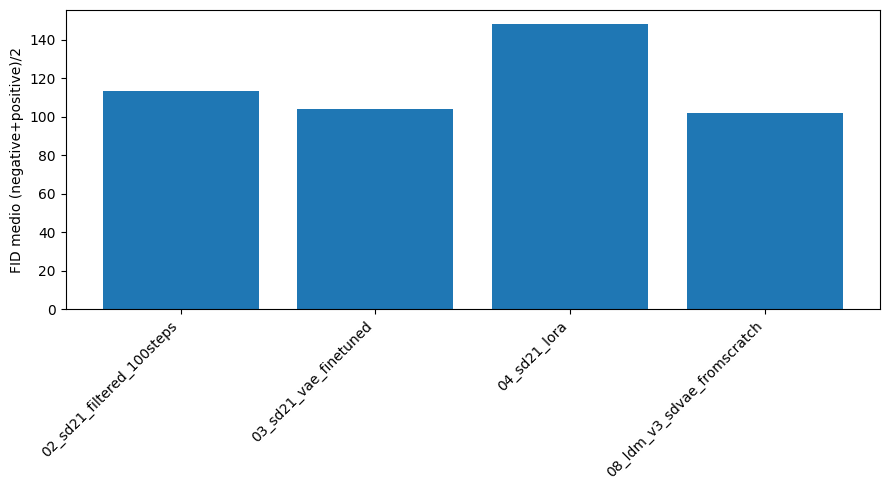

In [3]:

two = tables["two_class_comparison"]
ok_rows = [r for r in two if r["status"] == "ok"]
incomplete = [r["generator_id"] for r in two if r["status"] != "ok"]
print(f"generatori con confronto due-classi completo: {len(ok_rows)}")
print(f"generatori con metriche incomplete (esclusi dalla media, non da questa tabella): {incomplete}")

if ok_rows:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar([r["generator_id"] for r in ok_rows], [r["FID"] for r in ok_rows])
    ax.set_ylabel("FID medio (negative+positive)/2")
    plt.xticks(rotation=45, ha="right")
    fig.tight_layout()
    out_dir = PROJECT_ROOT / "results/generator_comparison/figures"
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / "two_class_fid_all_generators.png", dpi=200)


## D.3 Tabella finale (G02/G03/G04/G07/G08 + eventuali altri role=final_comparison) — spec 12.3

In [4]:

final = tables["final_comparison"]
for row in final:
    print(row["generator_id"], "FID=", row.get("FID"), "precision=", row.get("precision"), "recall=", row.get("recall"))


02_sd21_filtered_100steps FID= 113.59235000000001 precision= 0.5418499999999999 recall= 0.23975000000000002
03_sd21_vae_finetuned FID= 104.07775000000001 precision= 0.59955 recall= 0.07535
04_sd21_lora FID= 148.02055000000001 precision= 0.2928 recall= 0.00685
07_ldm_sdvae_extra1361 FID= None precision= None recall= None
08_ldm_v3_sdvae_fromscratch FID= 101.77404999999999 precision= 0.6025 recall= 0.019200000000000002


## D.4 Ablation (G01vG02, G02vG03, G02/G03vG04, G05vG06, G07vG08) — spec 12.4

In [5]:

for row in tables["ablation_comparison"]:
    deltas = {k: v for k, v in row.items() if k.startswith(("positive_delta", "negative_delta"))}
    print(row["ablation"], deltas or "(metriche incomplete per uno dei due generatori)")


sampling_steps_50_vs_100 (metriche incomplete per uno dei due generatori)
vae_base_vs_finetuned {'positive_delta_FID_b_minus_a': -13.765500000000003, 'positive_delta_IS_mean_b_minus_a': -0.3267000000000002, 'positive_delta_precision_b_minus_a': 0.06540000000000001, 'positive_delta_recall_b_minus_a': -0.19180000000000003, 'negative_delta_FID_b_minus_a': -5.2637, 'negative_delta_IS_mean_b_minus_a': -0.24189999999999978, 'negative_delta_precision_b_minus_a': 0.050000000000000044, 'negative_delta_recall_b_minus_a': -0.13699999999999998}
full_finetune_vs_lora {'positive_delta_FID_b_minus_a': 45.82270000000001, 'positive_delta_IS_mean_b_minus_a': -0.2931999999999999, 'positive_delta_precision_b_minus_a': -0.3144, 'positive_delta_recall_b_minus_a': -0.0822, 'negative_delta_FID_b_minus_a': 42.062899999999985, 'negative_delta_IS_mean_b_minus_a': -0.3378000000000003, 'negative_delta_precision_b_minus_a': -0.29910000000000003, 'negative_delta_recall_b_minus_a': -0.0548}
extra1361_effect {'positiv

## D.5 Sampling ablation G08 (25/50/75/100 step) — spec 12.4

In [6]:

for row in tables["sampling_ablation"]:
    print(row)


{'sampling_steps': 25, 'status': 'ok', 'run_dir': 'results/diffusers/08_ldm_v3_sdvae_fromscratch_sampling_st25_2058ec8ae46d'}
{'sampling_steps': 50, 'status': 'ok', 'run_dir': 'results/diffusers/08_ldm_v3_sdvae_fromscratch_sampling_st50_fee56a99e979'}
{'sampling_steps': 75, 'status': 'ok', 'run_dir': 'results/diffusers/08_ldm_v3_sdvae_fromscratch_sampling_st75_ece830e86b27'}
{'sampling_steps': 100, 'status': 'ok', 'run_dir': 'results/diffusers/08_ldm_v3_sdvae_fromscratch_sampling_st100_08011d0b6145'}


## D.6 Nota metodologica

Nessun vincitore downstream viene dichiarato da questo notebook: la selezione dei generatori per Stage 2 avviene esclusivamente su validation dei classificatori (`scripts/finalize_validation_stage.py --stage 1`), mai da FID/IS/PRDC da soli e mai dal test set.